# Figure2(Stackedbar) for bertopic

In [1]:
import os 
import numpy as np
import pandas as pd
from datetime import datetime

from setting_for_sda.color_setting import Color_Setting
from setting_for_sda.date_setting import Date_Setting
from setting_for_sda.path_setting import path_list
from lib.utils.datetime_handler import calc_rel_period

import lib.stats.stats as st
from lib.utils.statistics import *
from matplotlib import pyplot as plt

import matplotlib as mpl
from lib.visualization.plot_generator import PlotGen
import lib.visualization.figure_setting as figure_setting
from lib.visualization.distribution_collector import (proportion_calc_for_topic, 
                                                      collect_top_bottom_topic, 
                                                      sort_distribution_by_list,
                                                      calc_top_bottom_tags_prop)
mpl.rcParams['font.family'] = figure_setting.init_font()
mpl.rcParams.update(figure_setting.fig_setting)


Helvetica /home/mghan/.fonts/Helvetica/Helvetica Oblique.ttf
Registered font name: Helvetica


In [2]:
def draw_bar_plot_for_bertopic(idx_num, proportion_dict, list_10, plotgen):
    fig, axs = plt.subplots(1, 2, figsize=(4.8, 2.6), constrained_layout=True,  dpi=300)
    color_list = Color_Setting.color_list
    alpha_list = [1, 1, 0.7]
    panel_labels = ['A.', 'B.', 'C.', 'D.']

    ### stacked topic plots
    for i, (title, proportion) in enumerate(proportion_dict.items()):
        plotgen.draw_topic_stack(
            axs[i],
            title,
            proportion,
            list_10[title],
            color_list[i],
            alpha_list[i],
            ''
        )


    fig.supxlabel("Week relative to ChatGPT release", fontsize=figure_setting.FONT['label'])
    fig.supylabel('Accumulated topic share', fontsize=figure_setting.FONT['label'])
    plt.show()

    # filename = f"{idx_num}_bar_plot_{plotgen.selected_tags}_{plotgen.model}_{plotgen.year_range}.png"
    # plt.savefig(
    # os.path.join(plotgen.output_dir, filename),
    # dpi=300,
    # bbox_inches='tight'
    # )
    # plt.close()

In [3]:
def draw_scatter_line_plot_for_bertopic(idx_num, proportion_dict, plotgen):
    fig, axs = plt.subplots(1, 2, figsize=(4.8, 2.6), constrained_layout=True,  dpi=300)
    color_list = Color_Setting.color_list
    alpha_list = [1, 1, 0.7]
    panel_labels = ['A.', 'B.', 'C.', 'D.']

    ### stacked topic plots
    for i, (title, proportion) in enumerate(proportion_dict.items()):
        x = list(sorted(proportion['rel_week'].unique()))
        y = list(proportion.groupby('rel_week')['proportion'].sum())


        plotgen.draw_topic_regression(
            axs[i],
            title,
            x,
            y, 
            color_list[i],
            alpha_list[i],
            panel_labels[i]
        )


    fig.supxlabel("Week relative to ChatGPT release", fontsize=figure_setting.FONT['label'])
    fig.supylabel('Accumulated topic share', fontsize=figure_setting.FONT['label'])
    # filename = f"{idx_num}_scatter_plot_{plotgen.selected_tags}_{plotgen.model}_{plotgen.year_range}.png"
    # plt.savefig(
    # os.path.join(plotgen.output_dir, filename),
    # dpi=300,
    # bbox_inches='tight'
    # )
    plt.show()

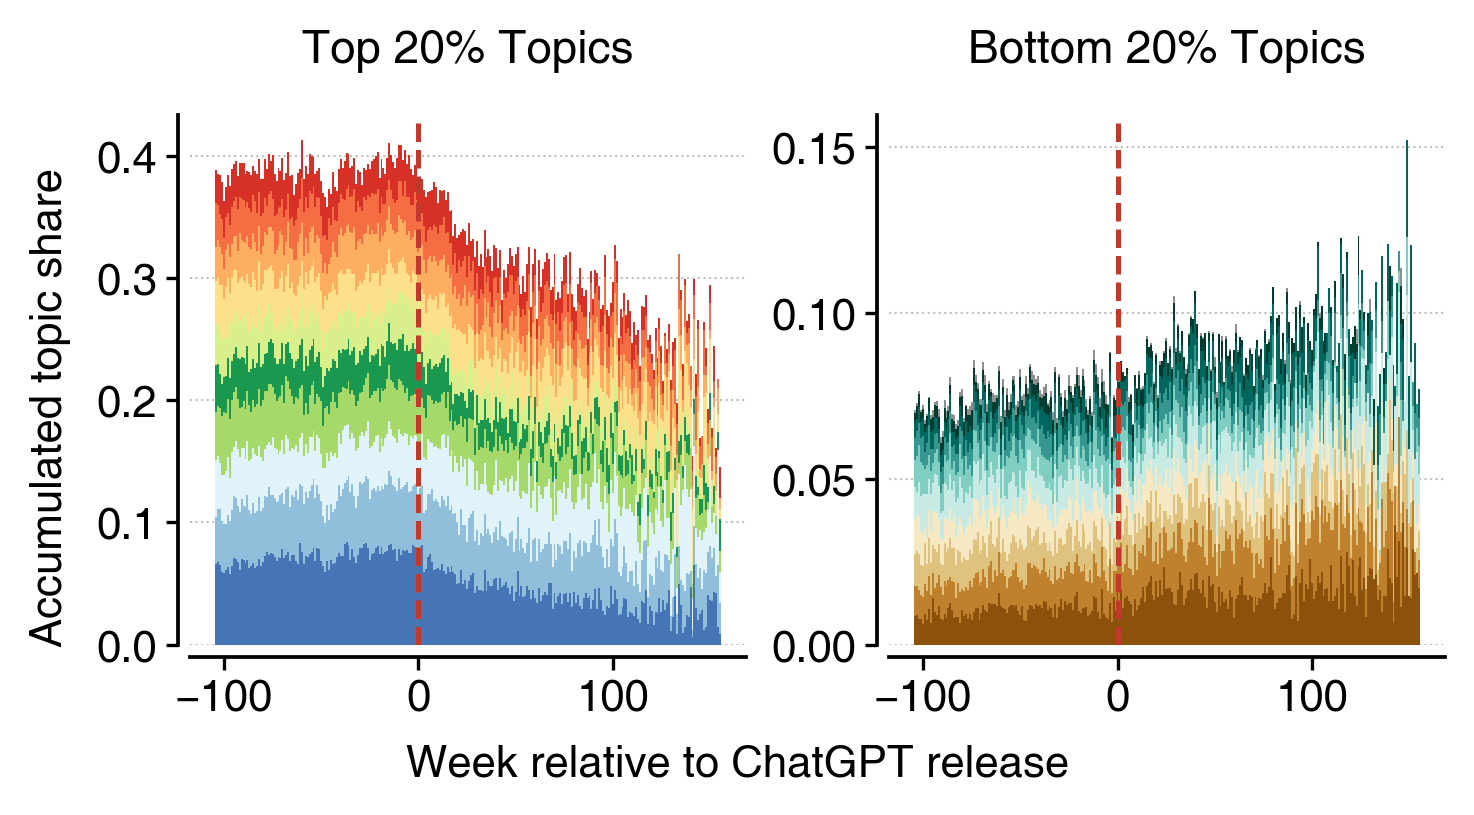

In [4]:
idx = 0
plotgen = PlotGen(idx = 200+idx, model_in_run='bert_based')


tmp = load_df(plotgen.data_dir, ['id' , 'creationdate' , 'title', 'tags', 'body', 'Topic'])
tmp = calc_rel_period(tmp, plotgen.std_date, date_col = 'creationdate', period = 7).reset_index()

proportion_dict = dict()
prop_df = proportion_calc_for_topic(tmp, 'rel_week', 'Topic')

top10list, mid30list, bot10list = collect_top_bottom_topic(prop_df, 'rel_week', 'Topic', 'proportion')

list_10 = {'Top 20% Topics' : top10list, 
            'Bottom 20% Topics' : bot10list, 
            'Mid 60% Topics': mid30list}


proportion_dict = {     'Top 20% Topics'        : sort_distribution_by_list(prop_df, top10list),   
                        'Bottom 20% Topics'     : sort_distribution_by_list(prop_df, bot10list),}


draw_bar_plot_for_bertopic(idx, proportion_dict, list_10, plotgen)

In [5]:
def draw_bar_plot_for_tag(idx_num, proportion_dict, plotgen):
    sharey = False ## 또는 sharey=False
    sharex = True ## 또는 sharex=False

    fig, axs = plt.subplots(1, 2, figsize=(5, 2.6), constrained_layout=True,  dpi=300)
    alpha_list = [0.6, 0.5, 0.5]
    color_list = ["#a6d96a", "#1a9850", "#1a9850"]
    panel_list = ['A.', 'B.', 'C.', 'D.']

    for idx, (title, proportion) in enumerate(proportion_dict.items()):
        x = list(proportion['rel_week'])
        y = list(proportion['pct_pct'])
        plotgen.draw_tag_bar(axs[idx]
                            , f'{title}' 
                            , x
                            , y
                            , color_list[idx]
                            , alpha_list[idx]
                            , ''
                            , set_ylim = False)
        

    fig.supxlabel("Weeks relative to ChatGPT release", fontsize=figure_setting.FONT['label'])
    fig.supylabel('Accumulated tag share', fontsize=figure_setting.FONT['label'])
    # filename = f"{idx_num}_bar_plot_{plotgen.option_dict['selected_tags']}_{plotgen.option_dict['model']}_{plotgen.option_dict['year_range']}.png"
    # plt.savefig(
    # os.path.join(plotgen.output_dir, filename),
    # dpi=300,
    # bbox_inches='tight'
    # )
    # plt.close(fig)
    plt.show()
    

/home/mghan/sopjt/git/so_data_availability/lib/visualization/plot_generator.py:369: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.yaxis.grid(is_visible, linestyle=':', linewidth=0.5, color='gray', alpha=0.5, zorder=0)


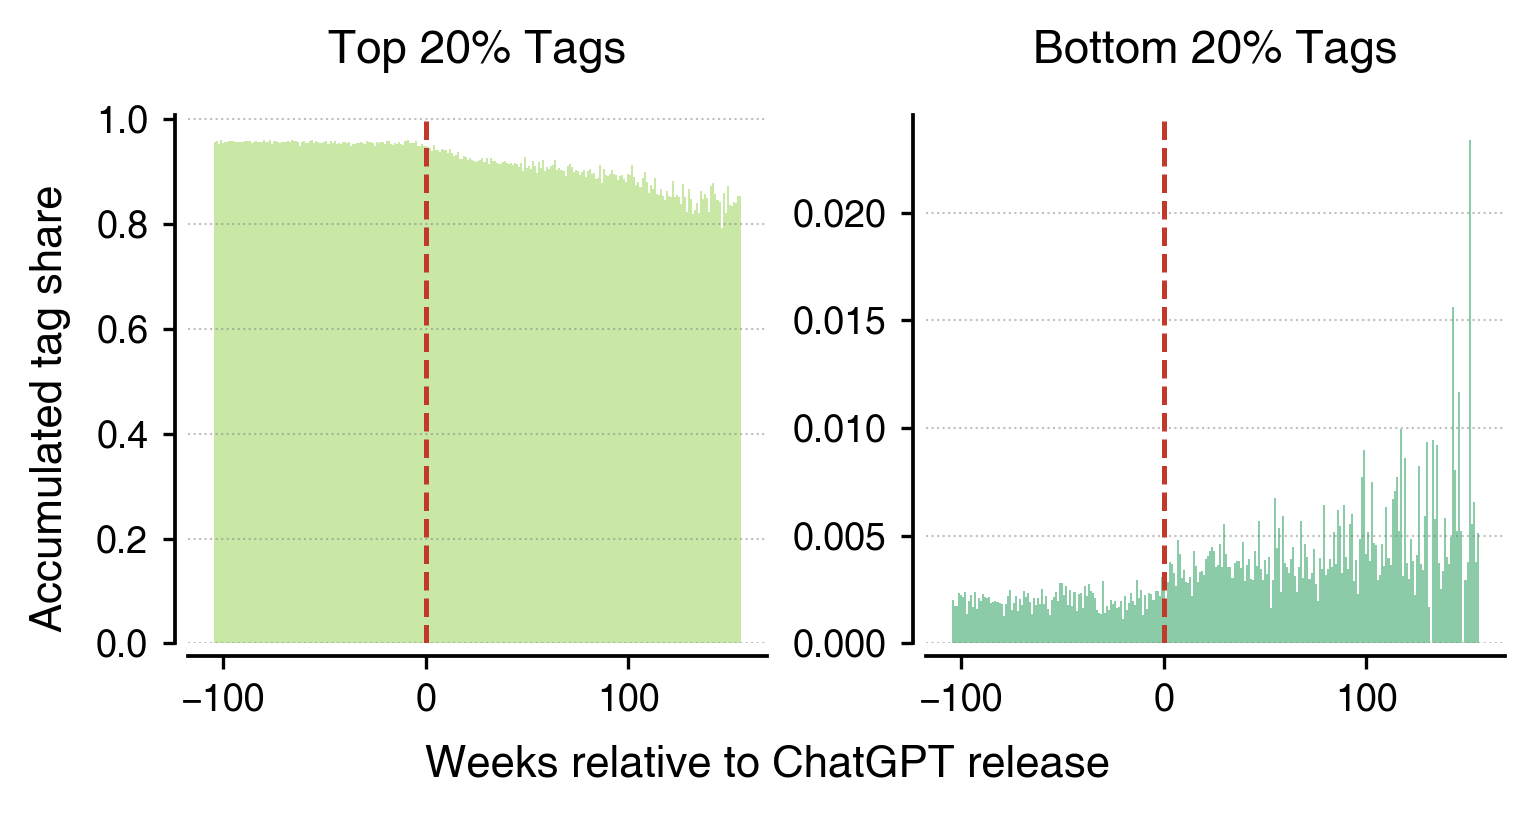

In [6]:
idx = 0
plotgen = PlotGen(idx = 100+idx, model_in_run='tag')


tmp = load_df(plotgen.data_dir, ['cdate' , 'id' , 'tag', 'cnt', 'tot_cnt', 'pct'])
tmp = calc_rel_period(tmp, plotgen.std_date, date_col = 'cdate', period = 7).reset_index()


proportion_dict = dict()
proportion_dict = calc_top_bottom_tags_prop(tmp)

draw_bar_plot_for_tag(idx, proportion_dict, plotgen)
# draw_scatter_line_plot_for_tag(idx, proportion_dict, plotgen)

    

[Start....] drawing figures for python language


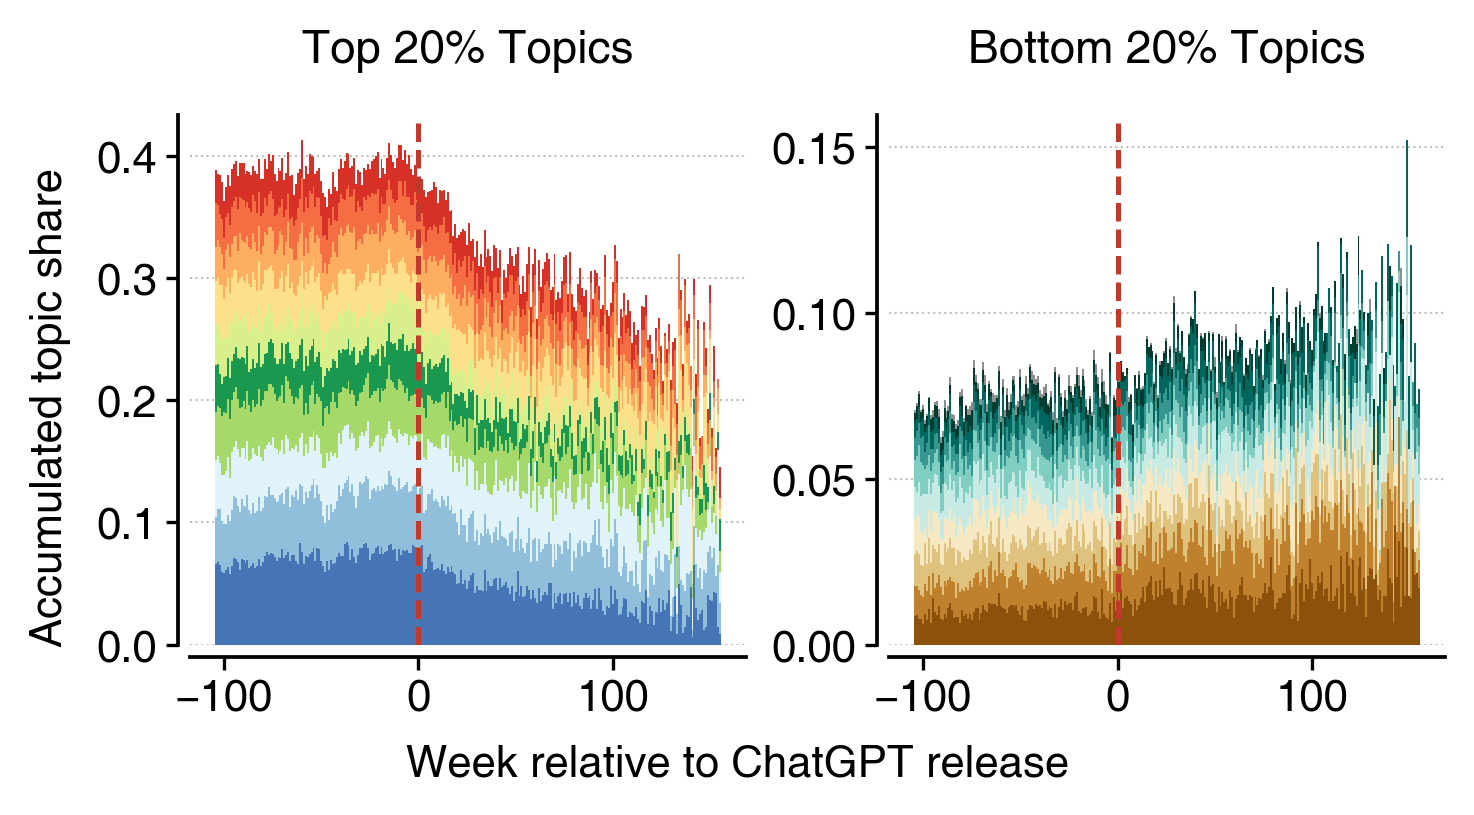

[Start....] drawing figures for javascript language


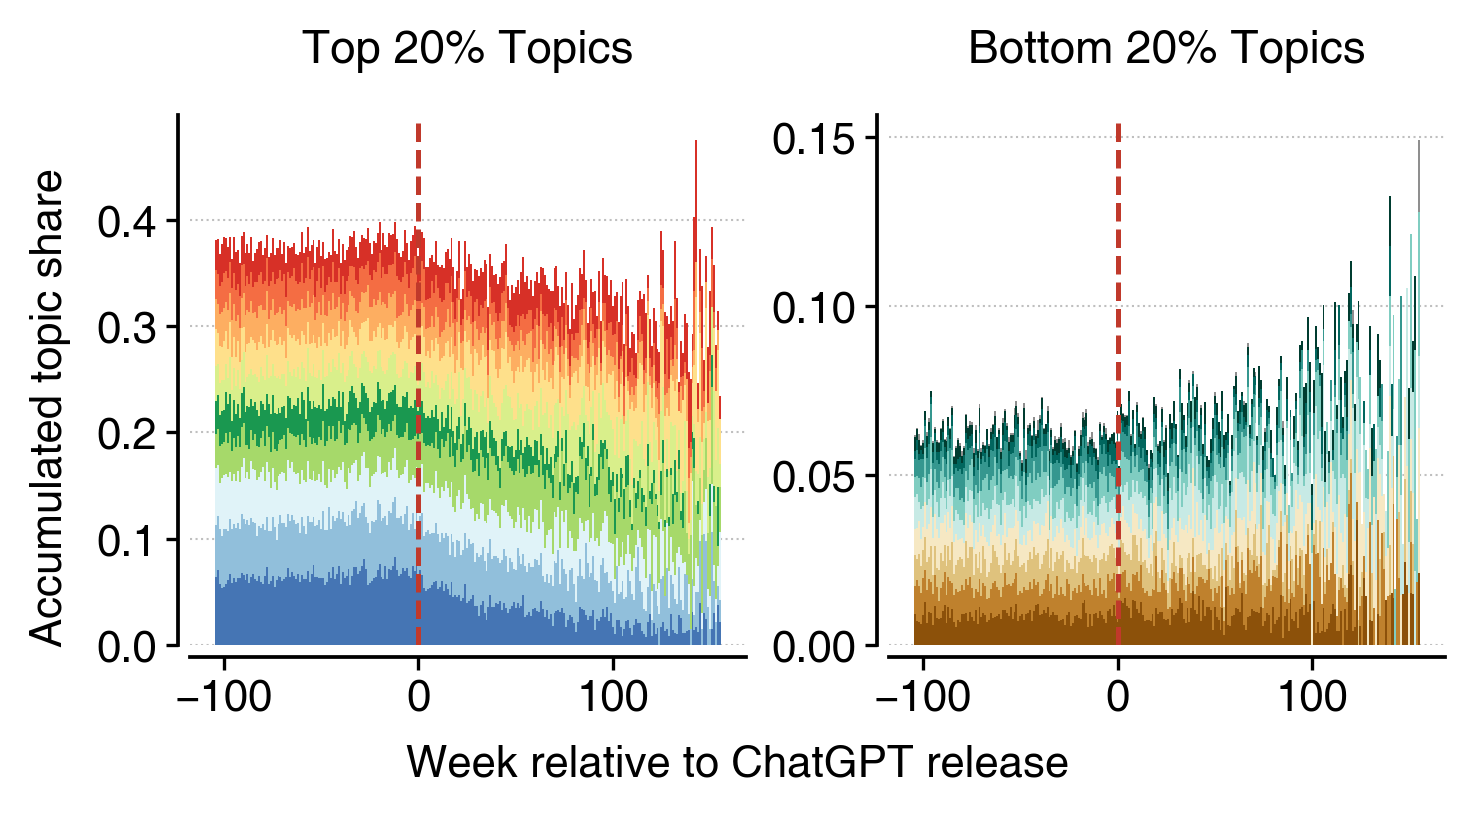

[Start....] drawing figures for java language


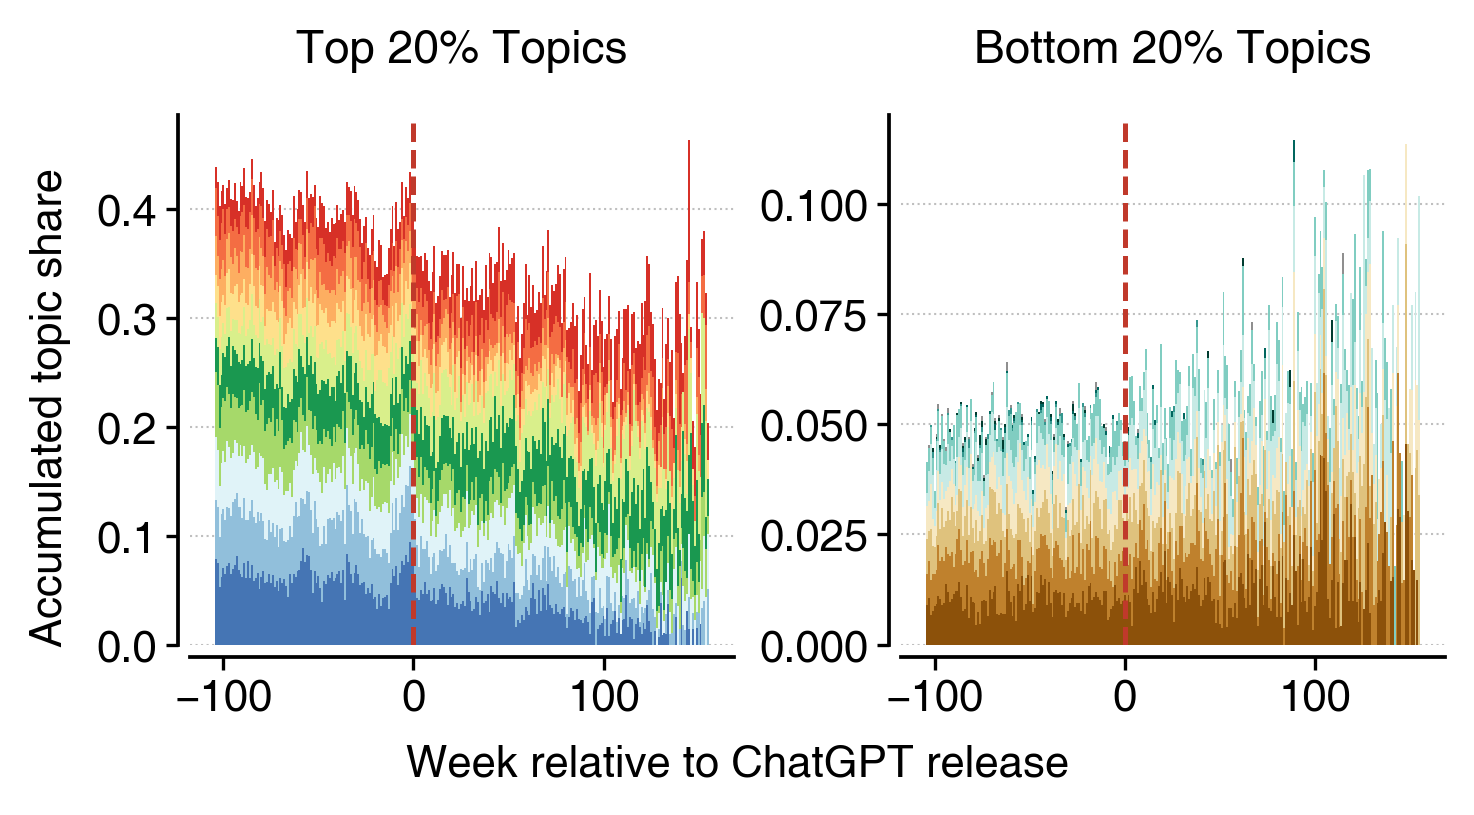

[Start....] drawing figures for c# language


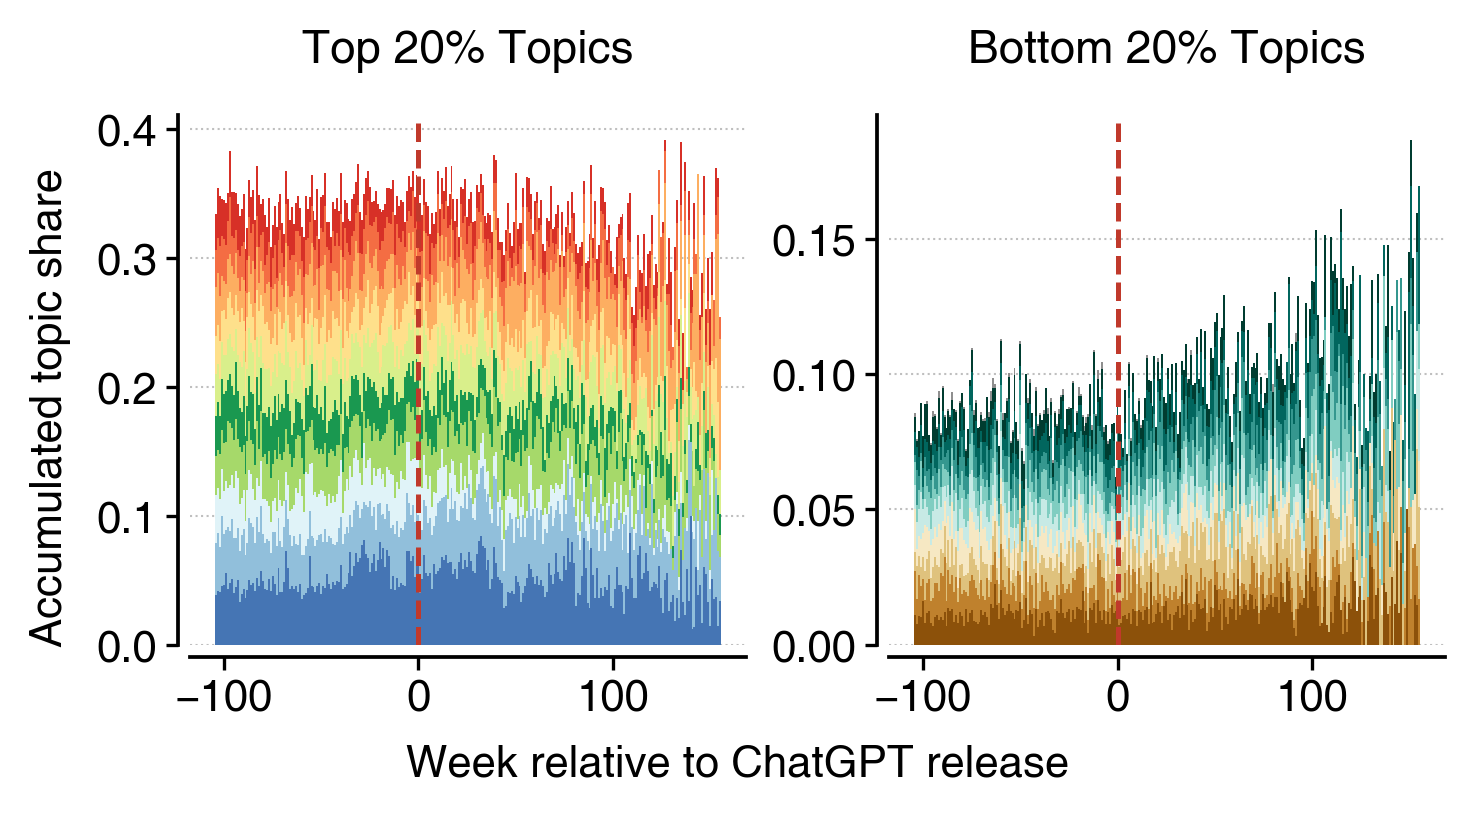

[Start....] drawing figures for c++ language


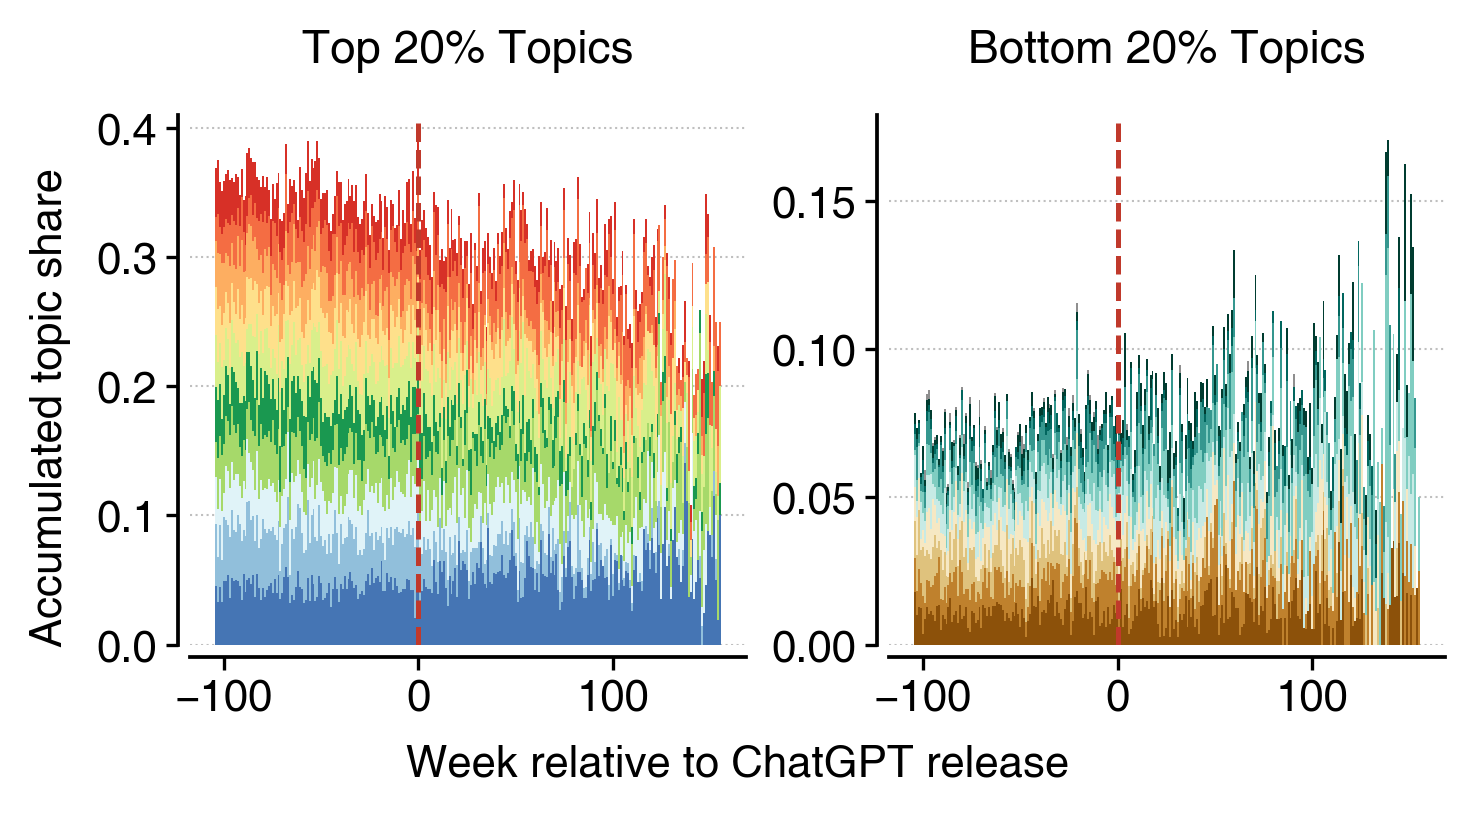

[Start....] drawing figures for c language


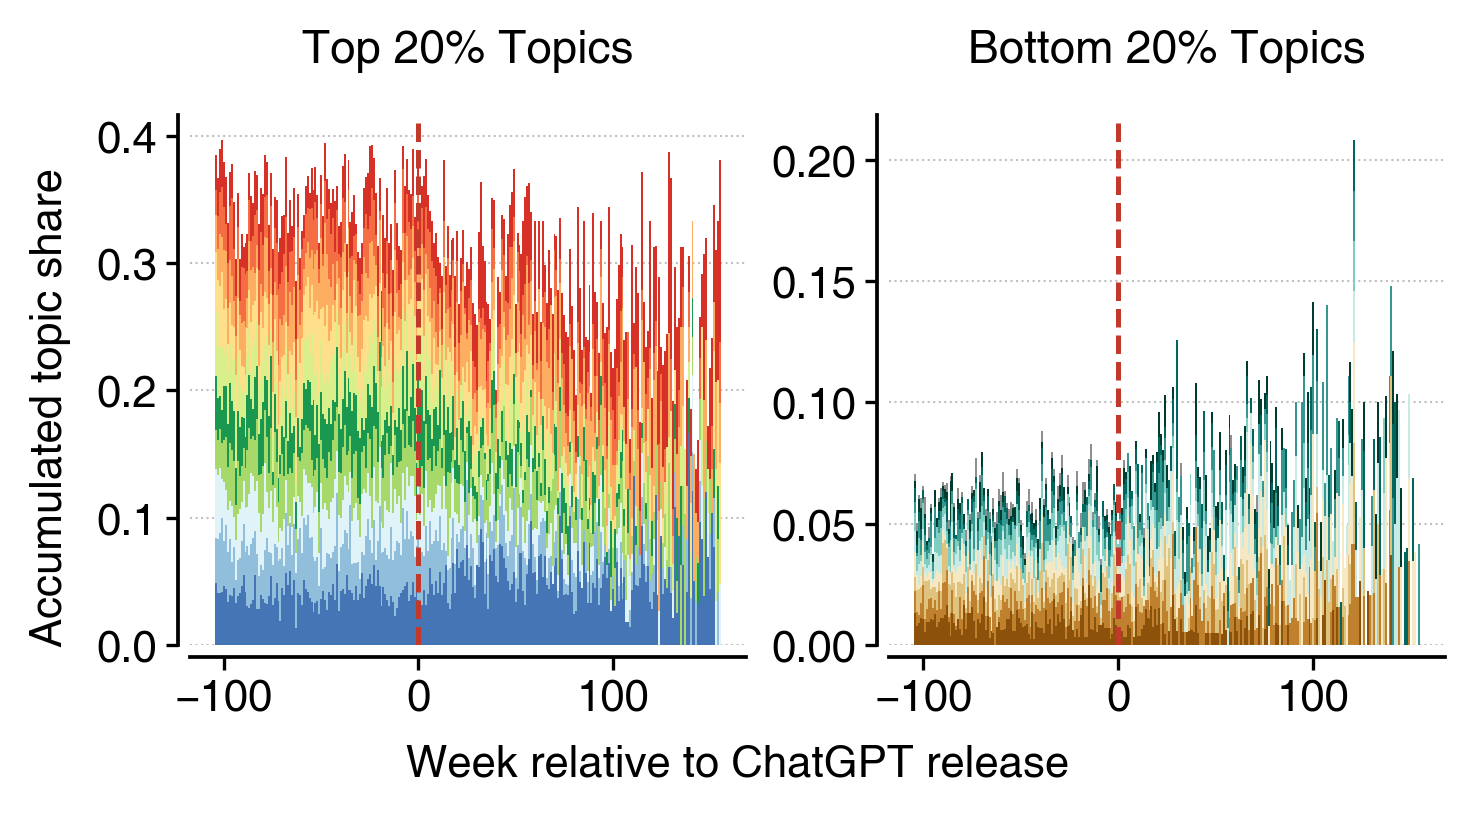

[Start....] drawing figures for r language


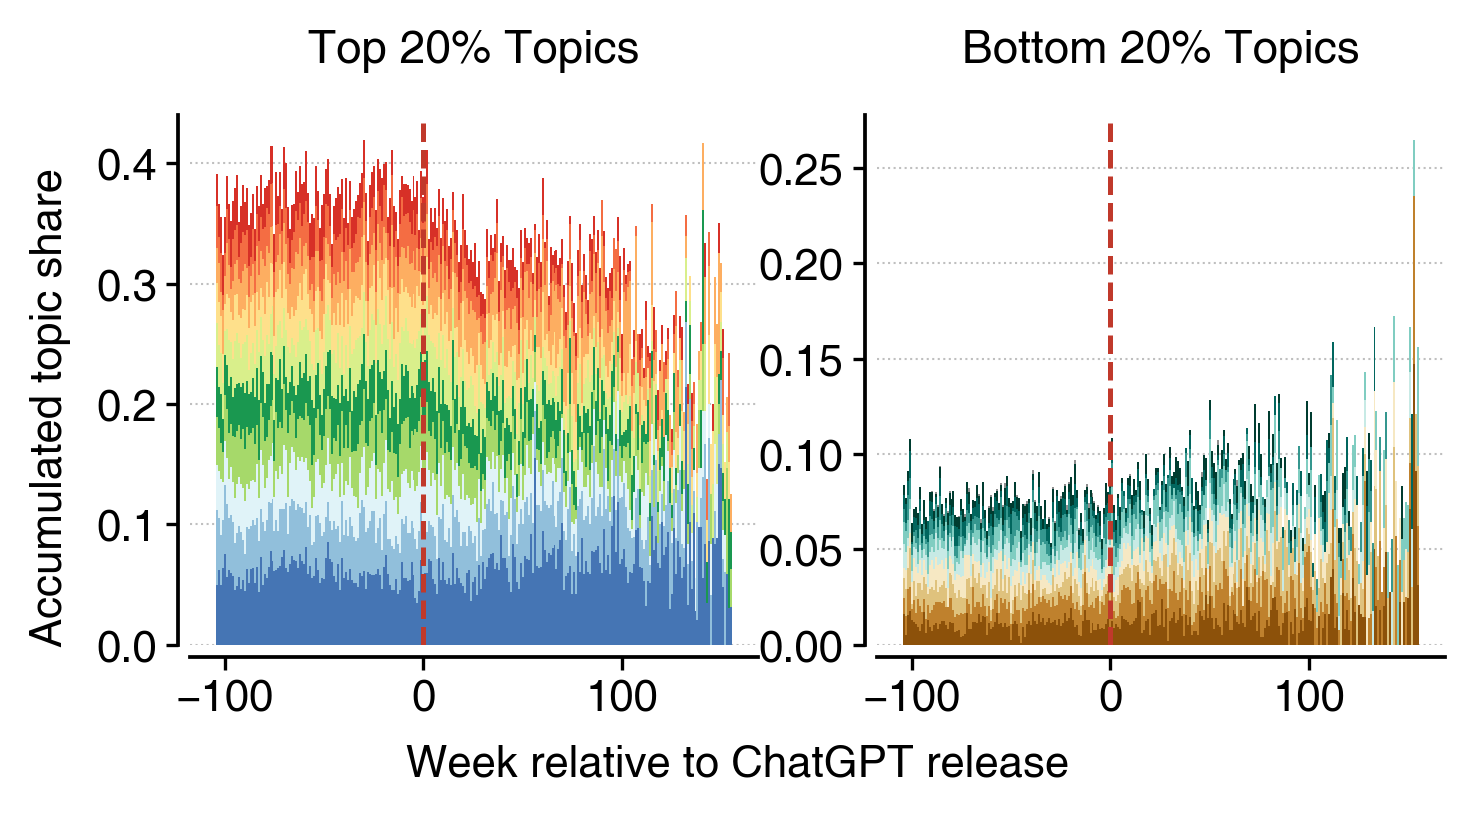

[Start....] drawing figures for php language


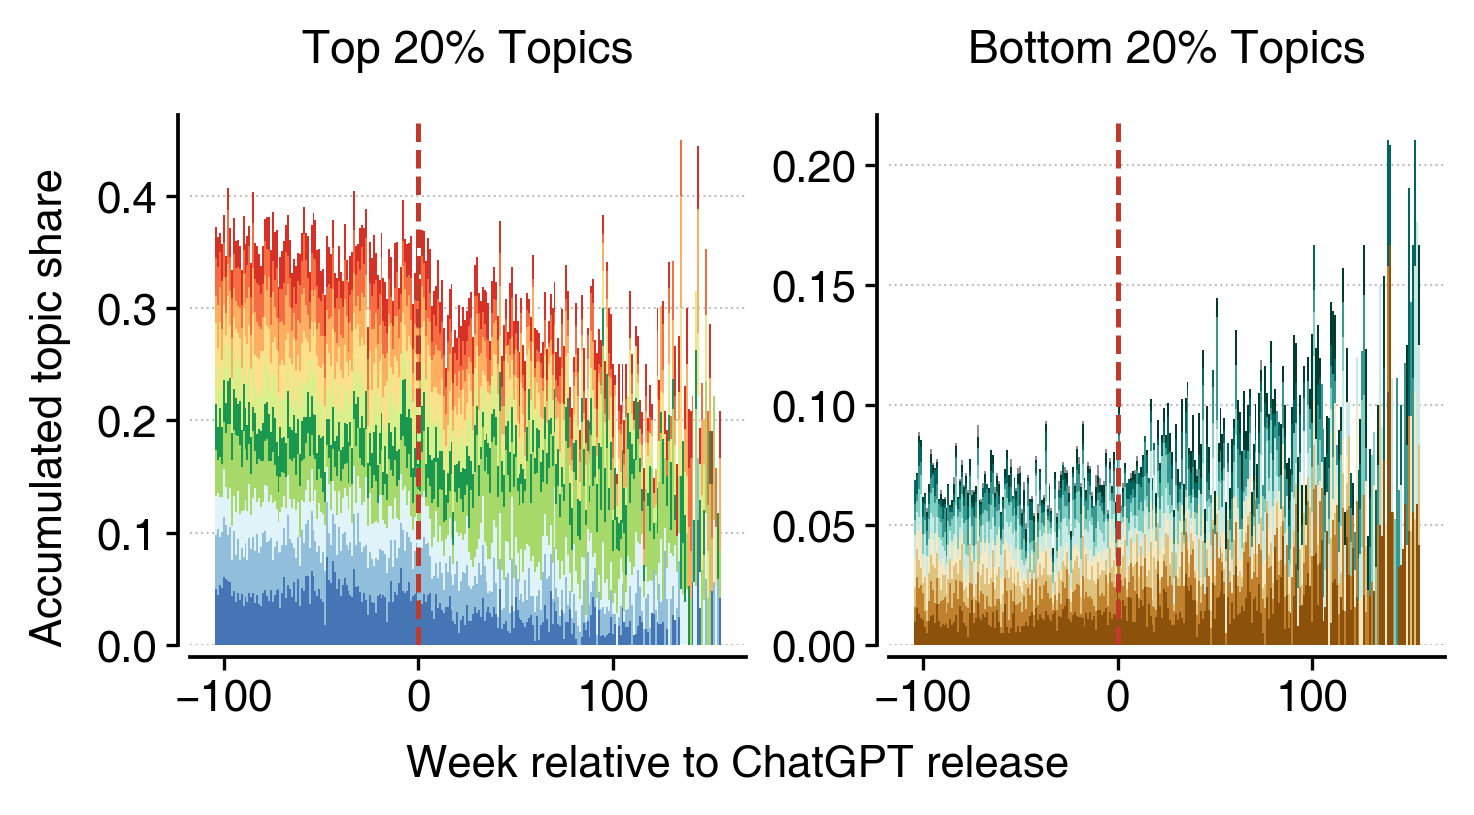

[Start....] drawing figures for swift language


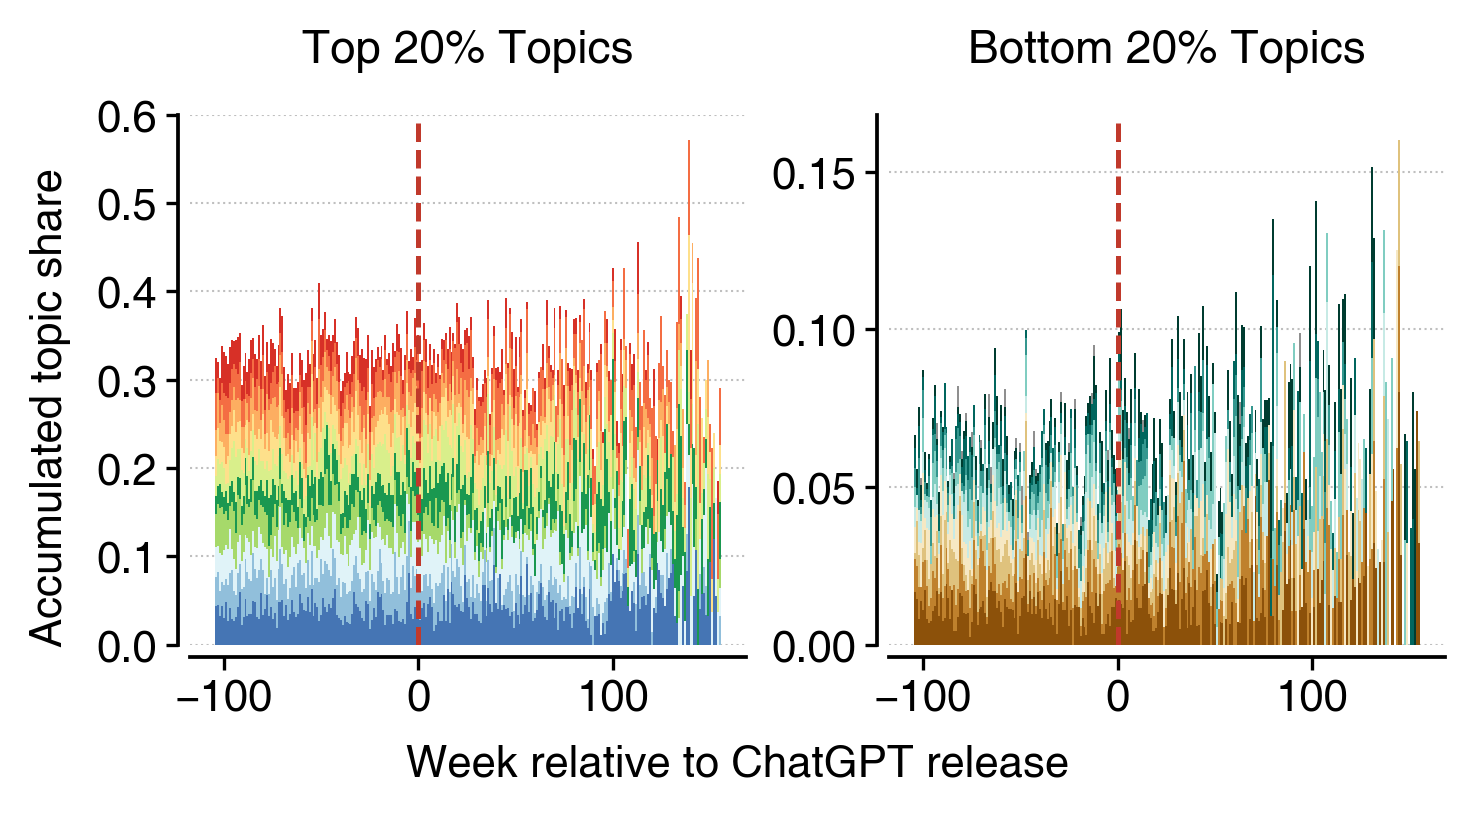

[Start....] drawing figures for kotlin language


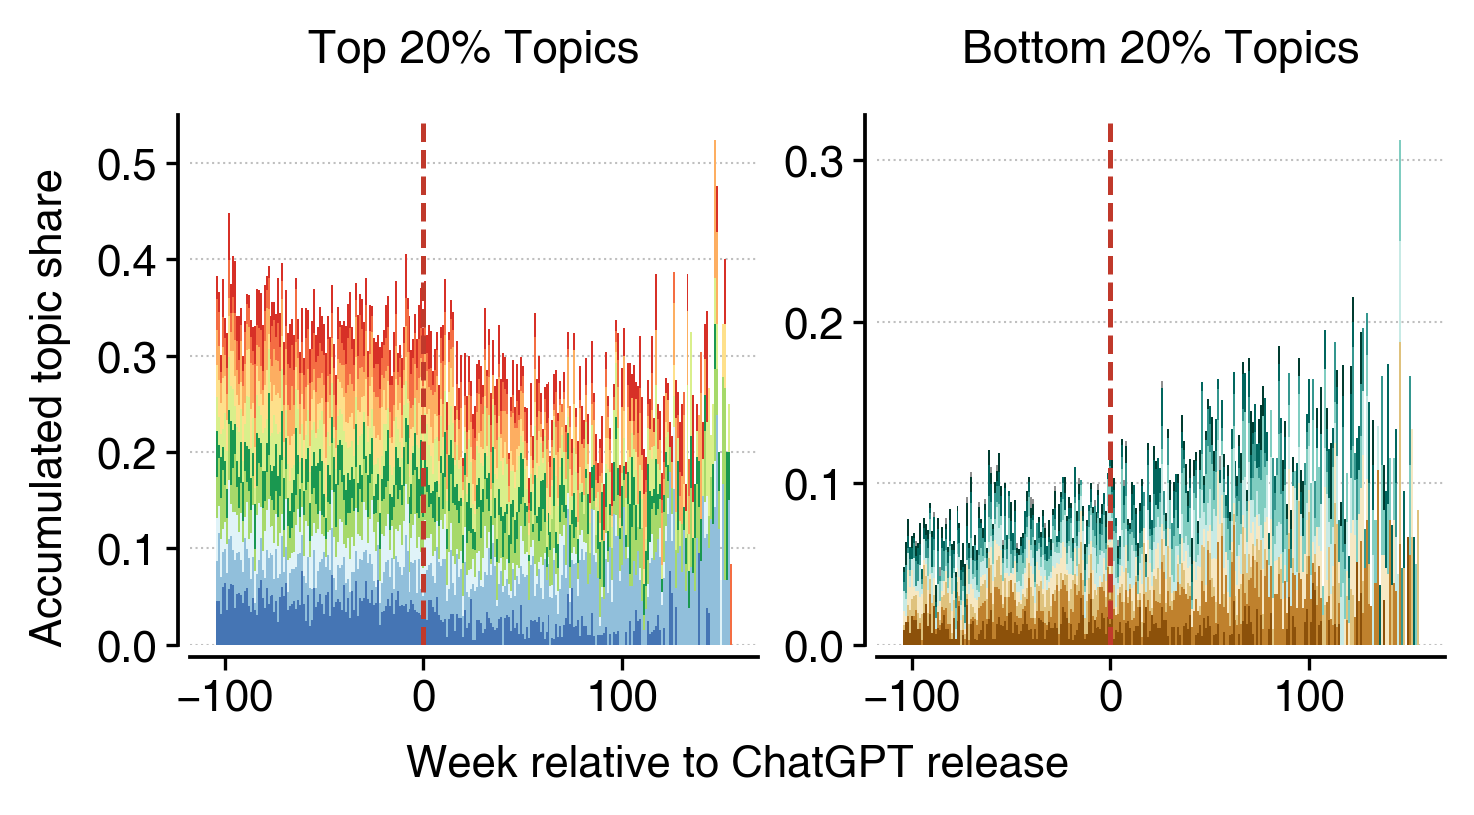

[Start....] drawing figures for dart language


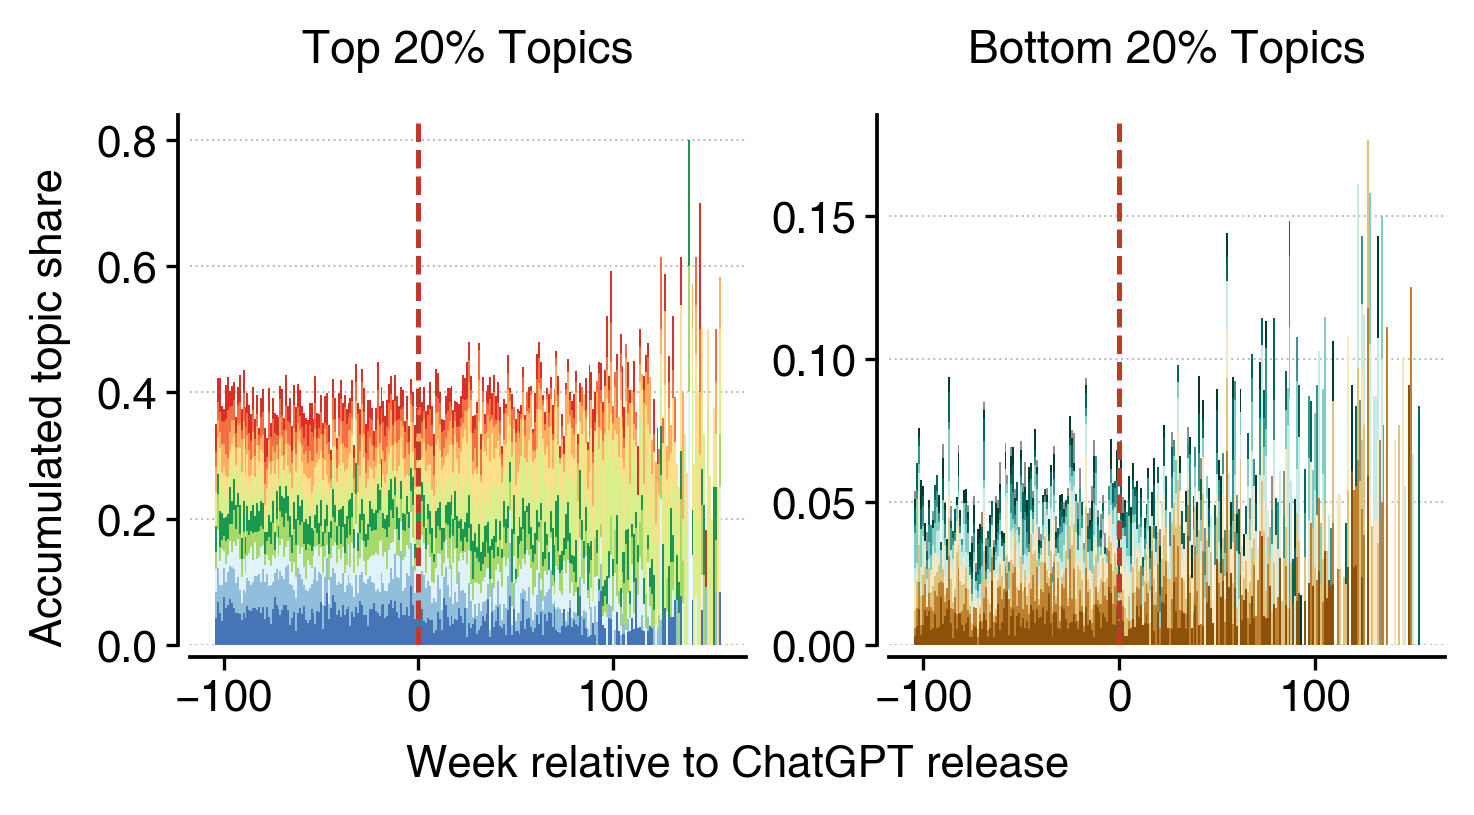

[Start....] drawing figures for typescript language


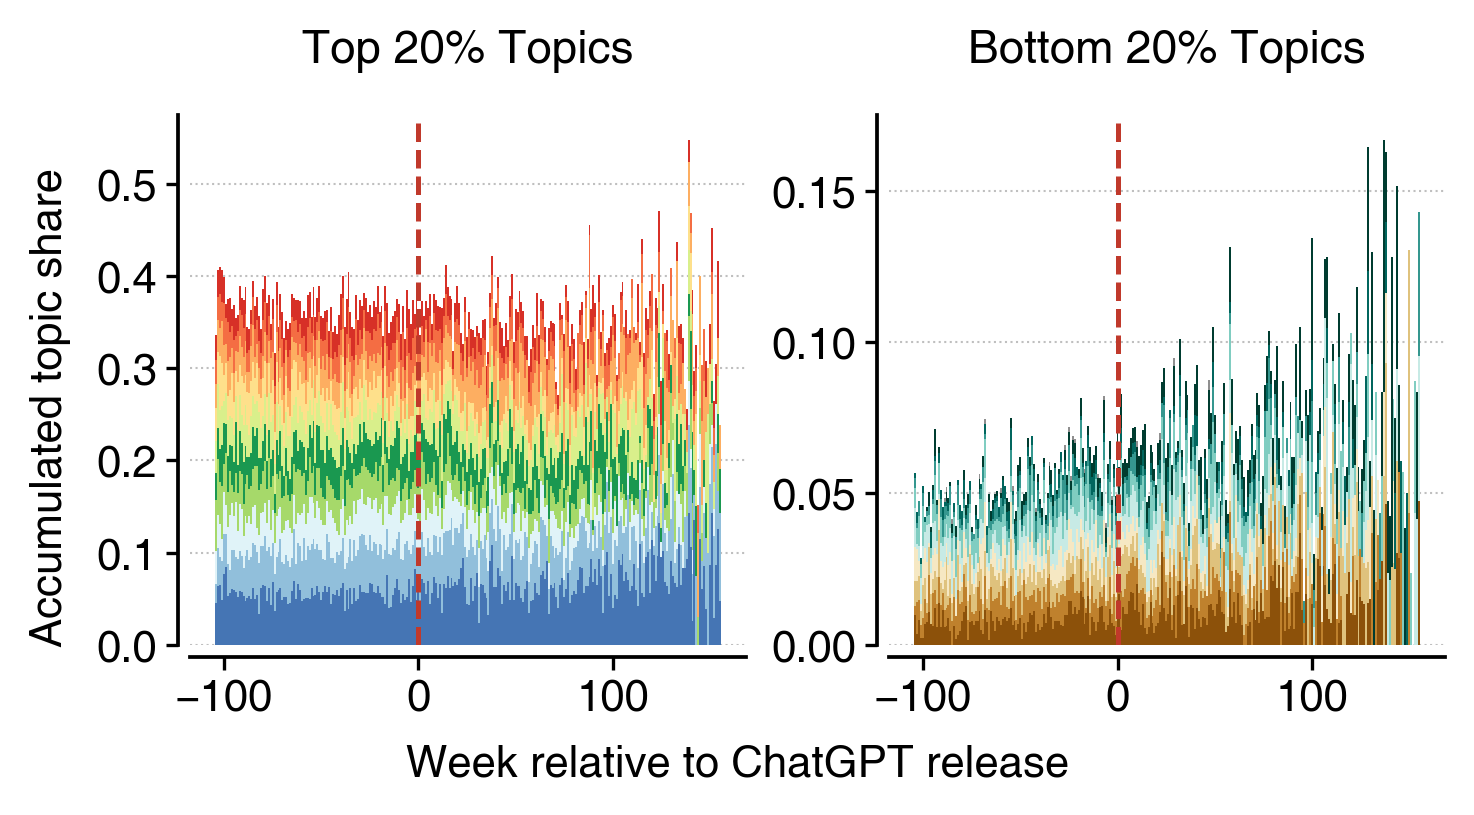

[Start....] drawing figures for go language


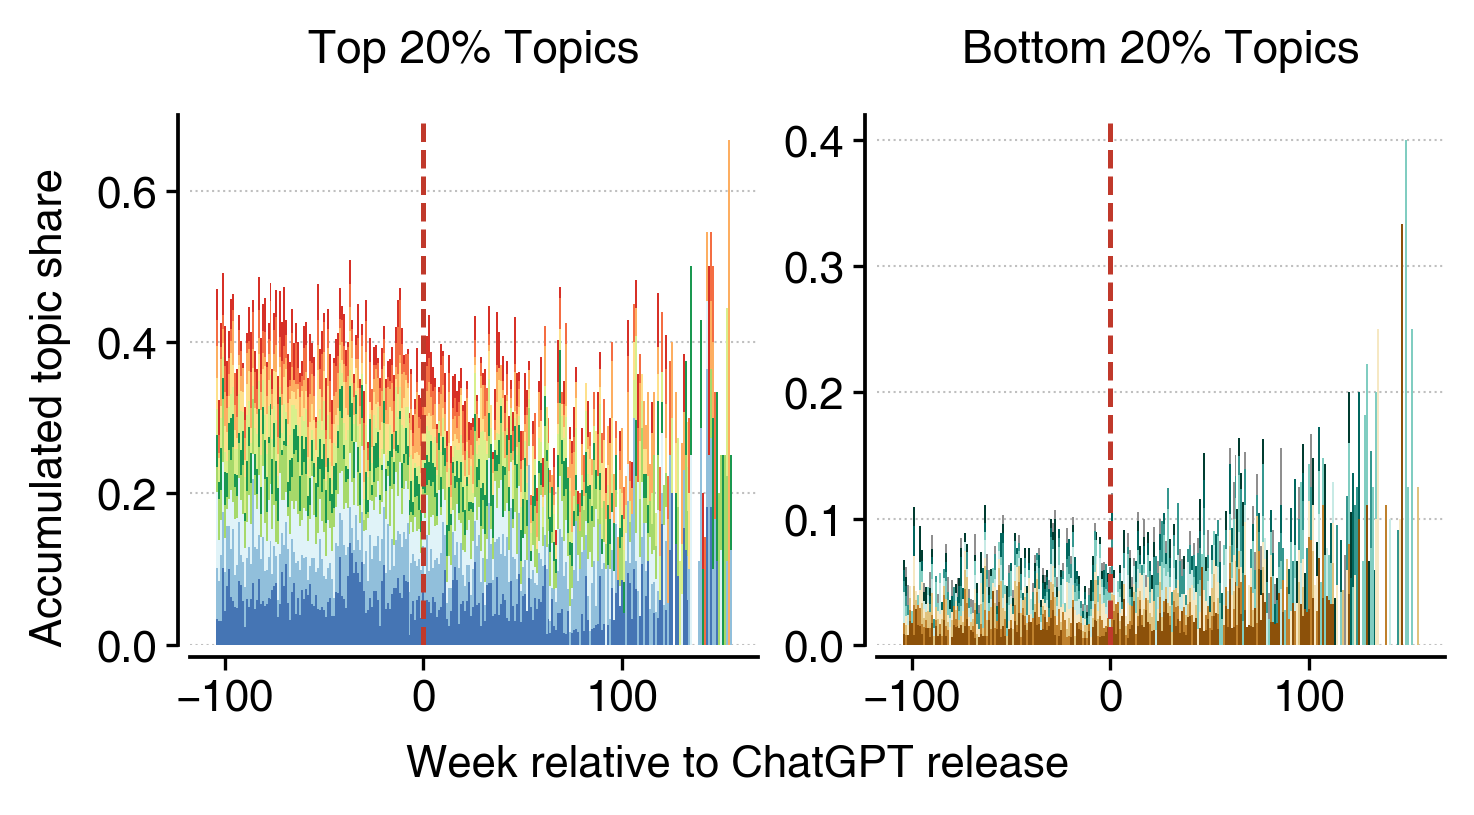

[Start....] drawing figures for ruby language


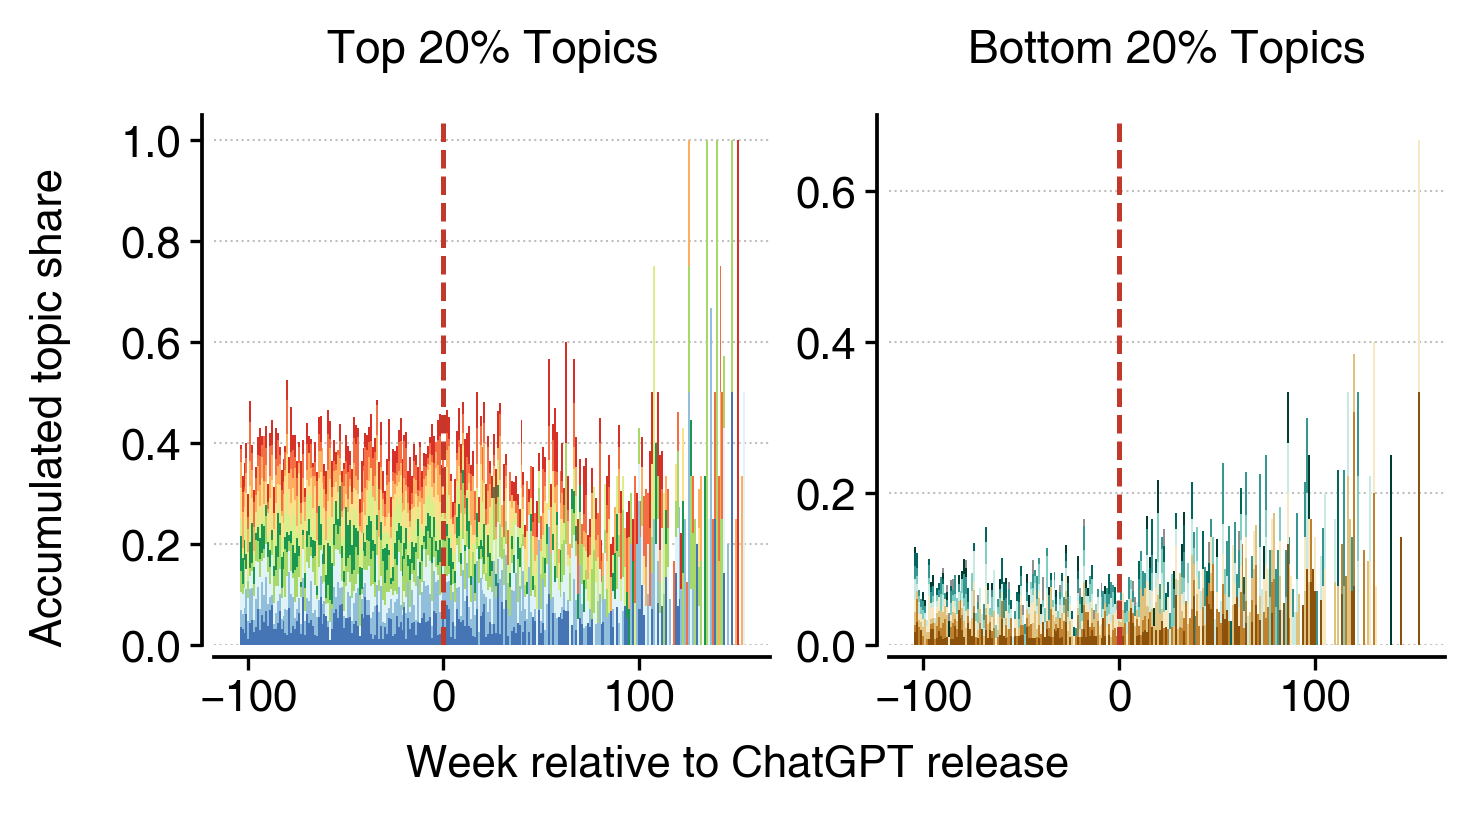

[Start....] drawing figures for rust language


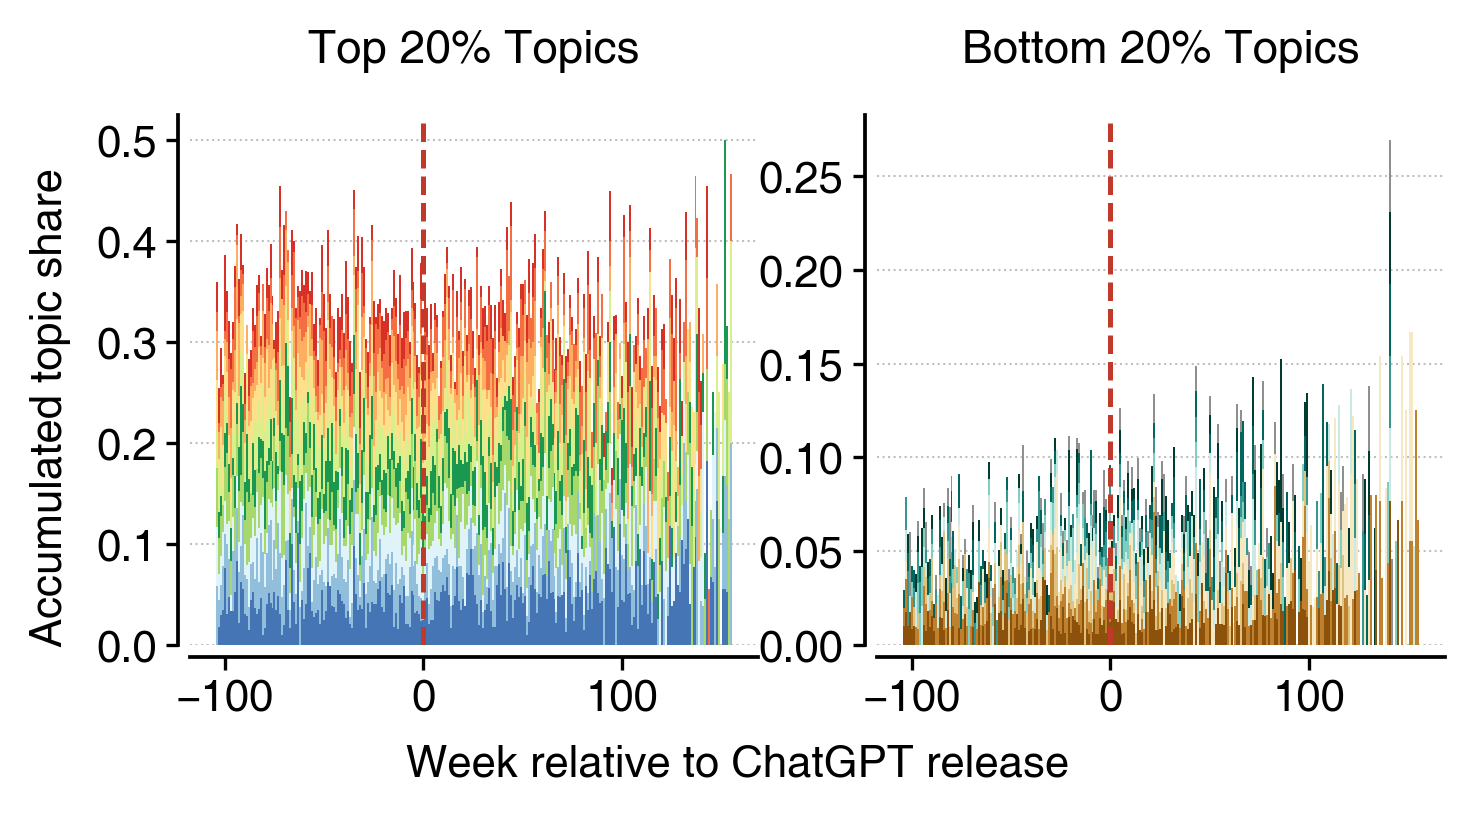

[Start....] drawing figures for scala language


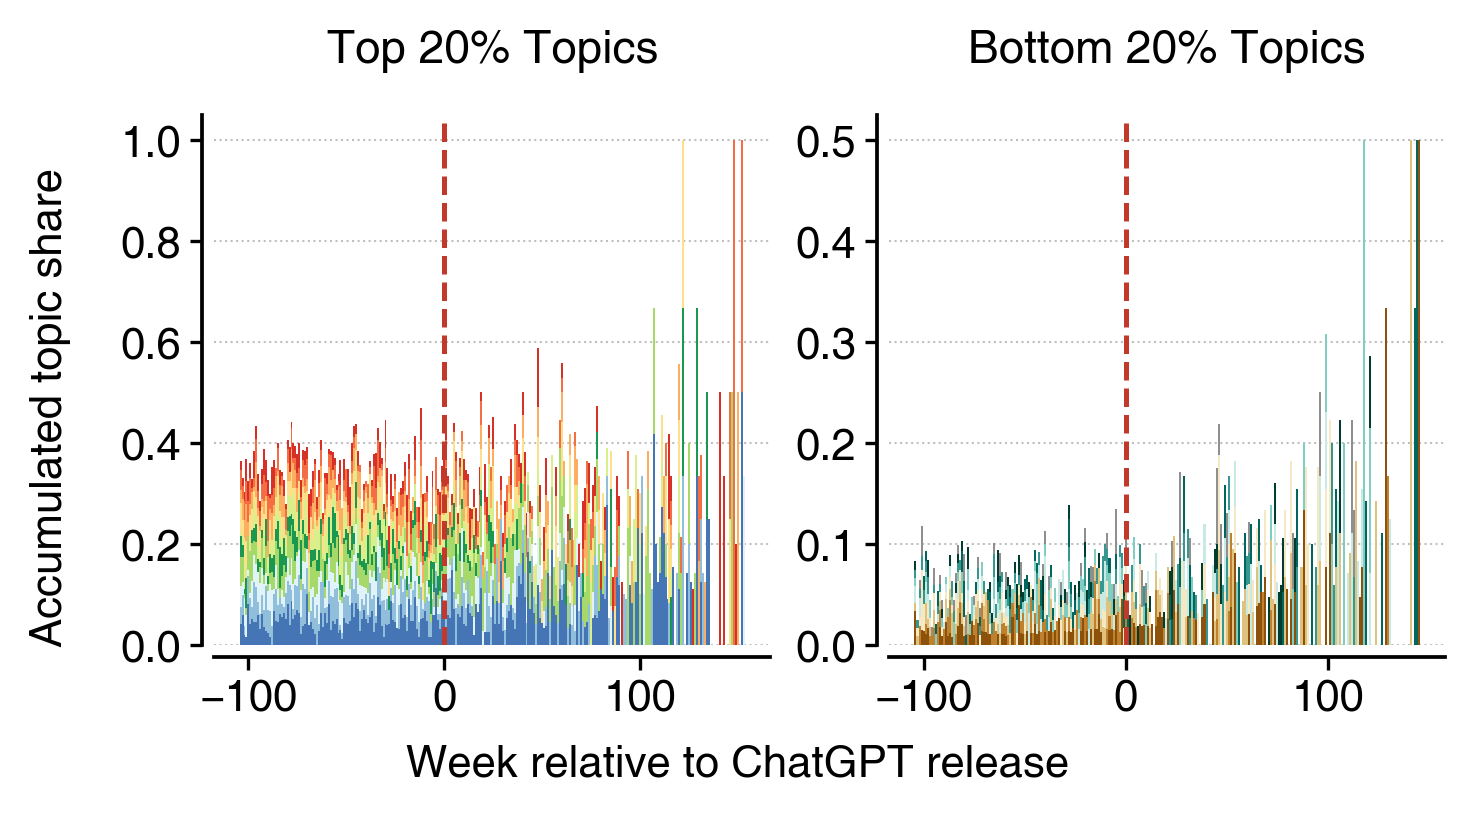

[Start....] drawing figures for julia language


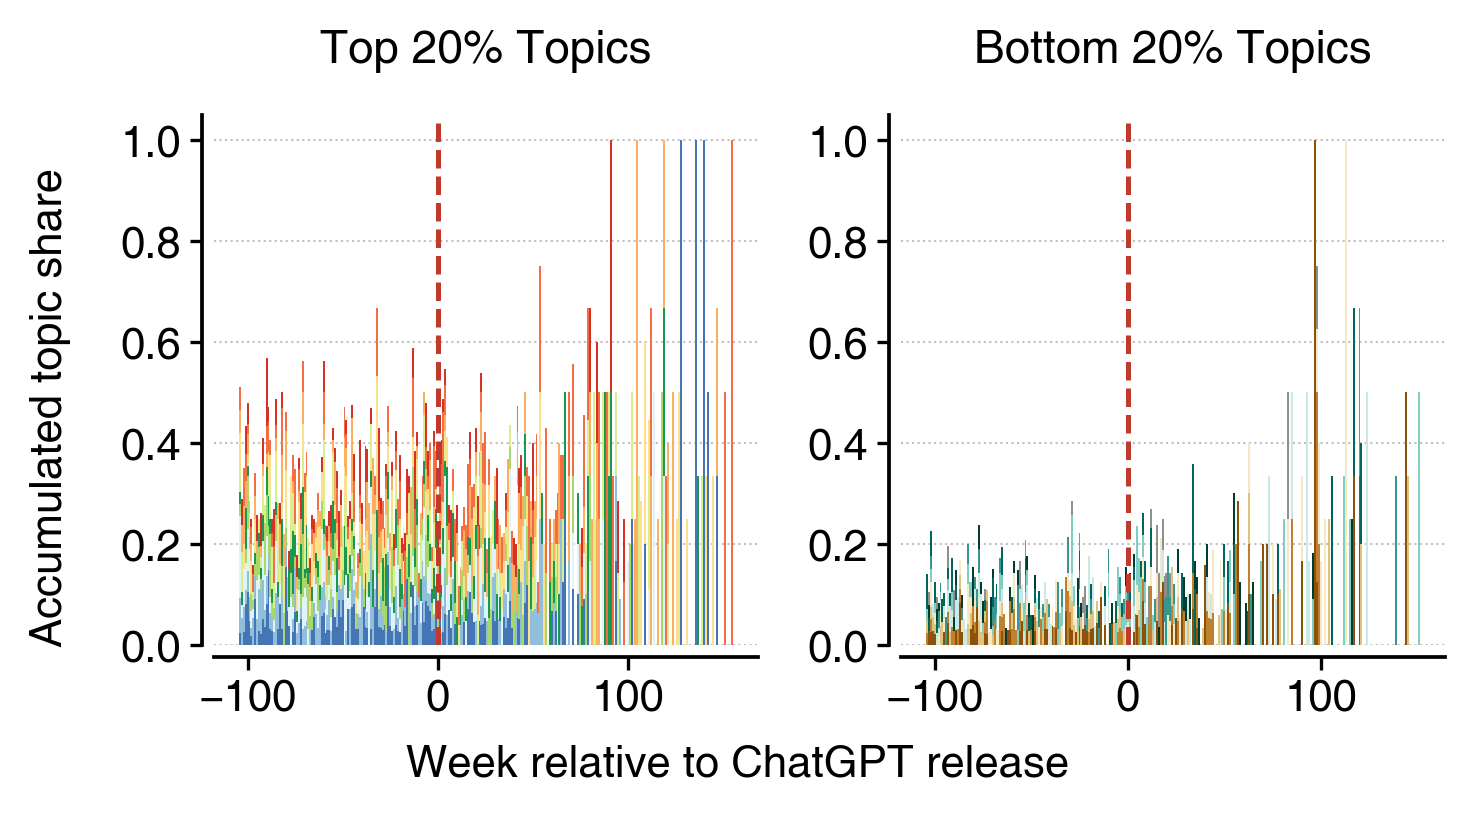

[Start....] drawing figures for matlab language


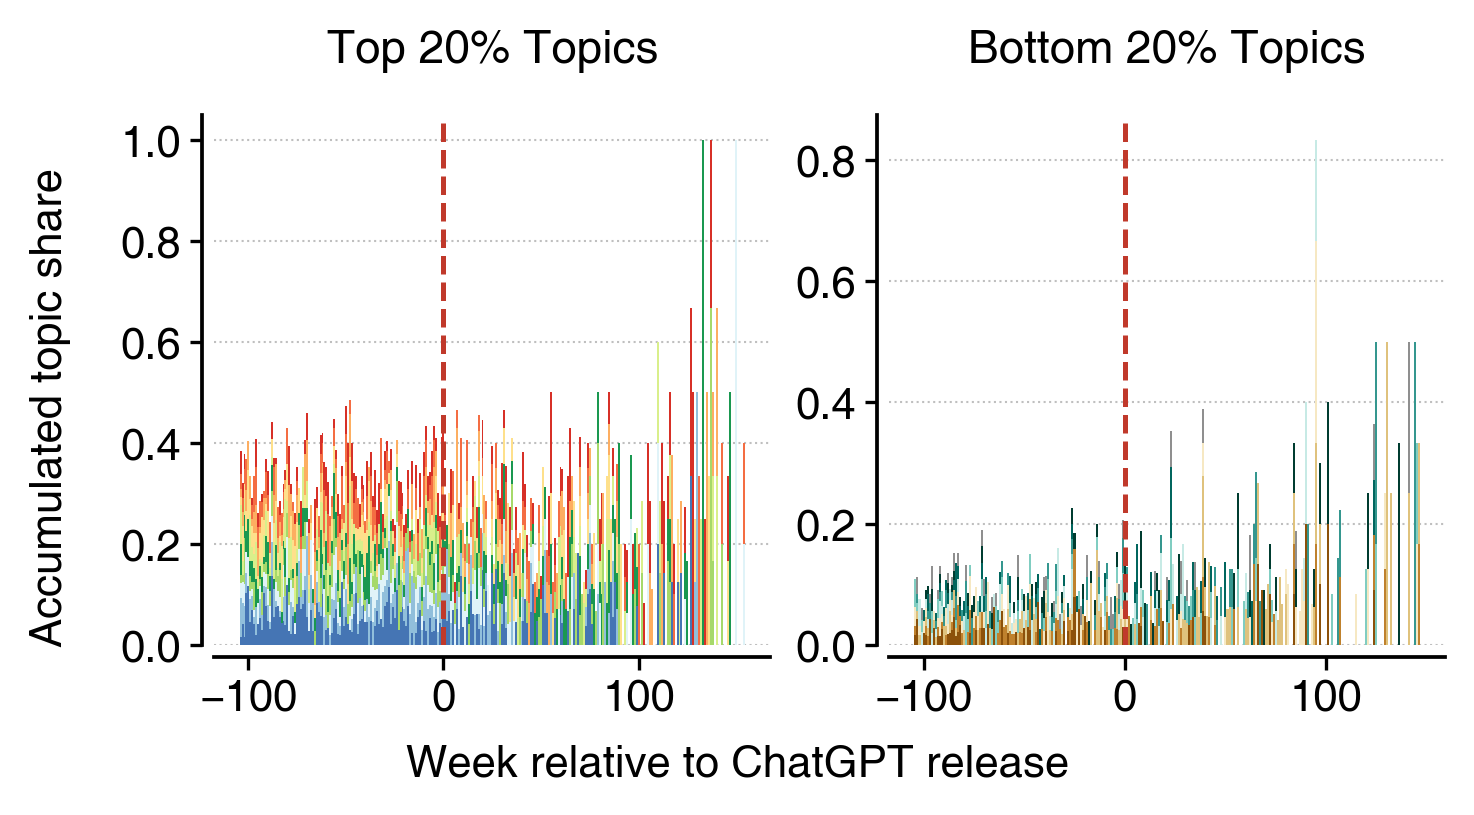

[Start....] drawing figures for groovy language


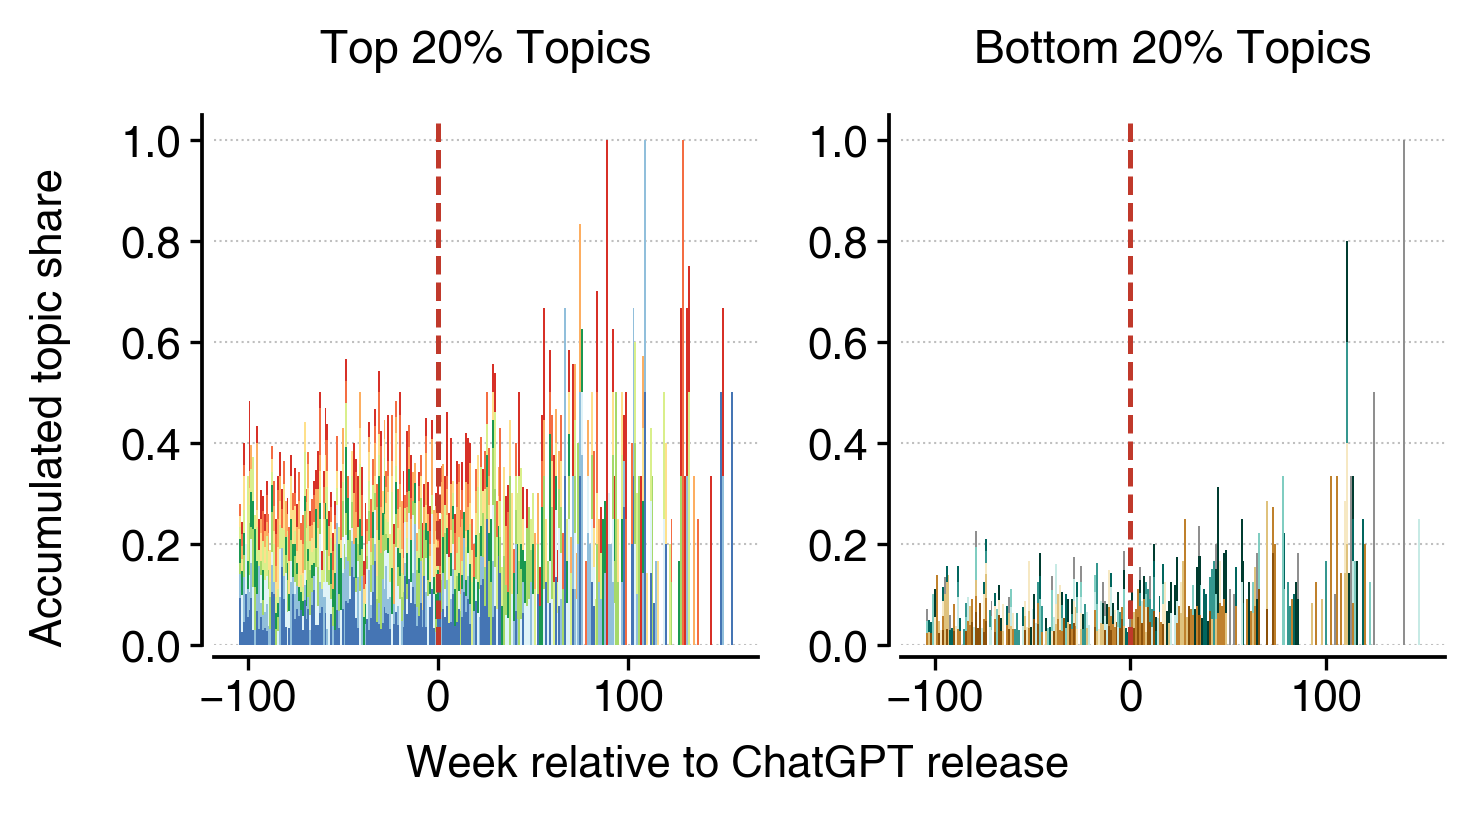

[Start....] drawing figures for objective-c language


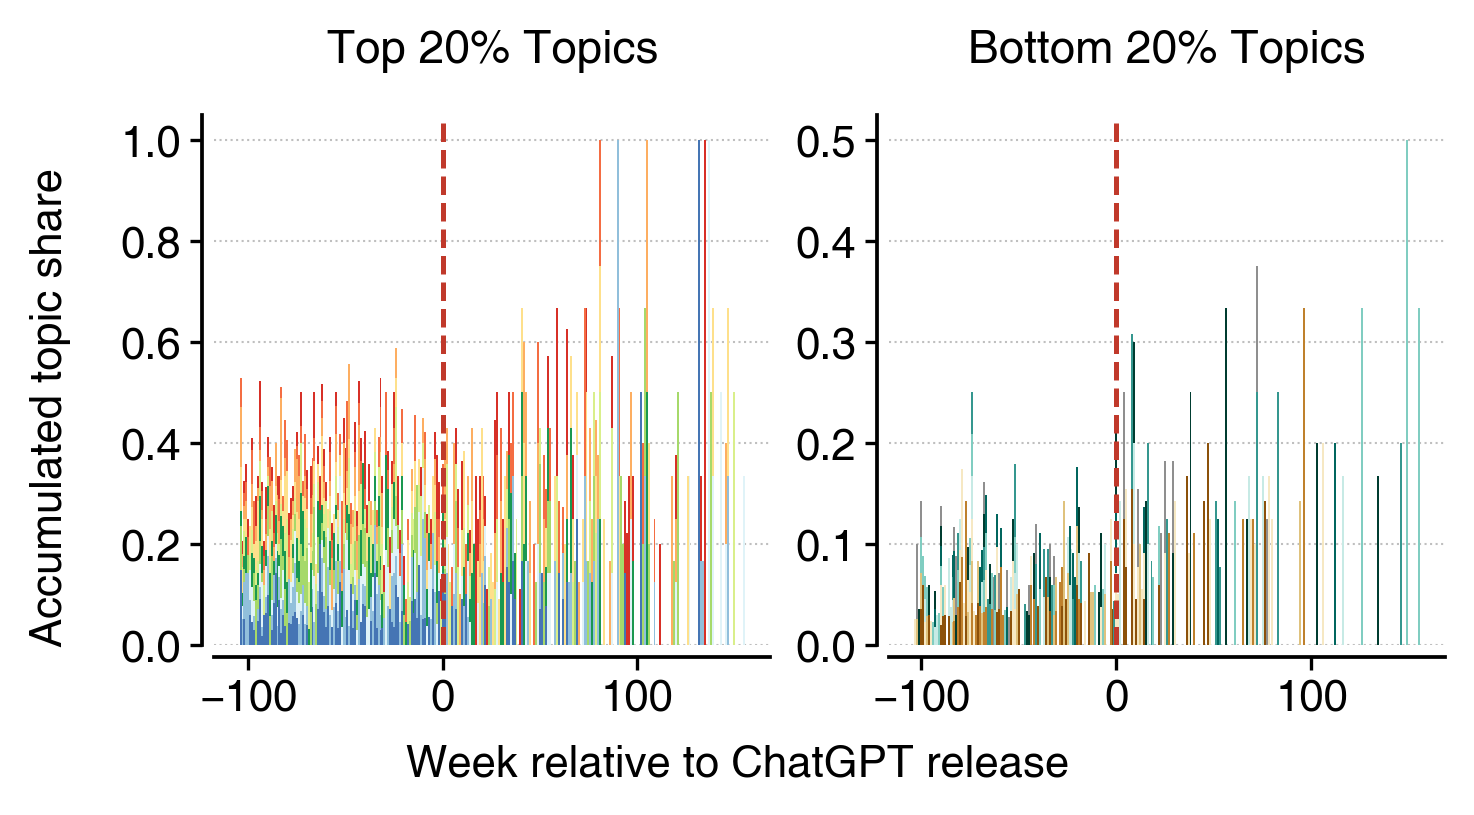

[Start....] drawing figures for vb.net language


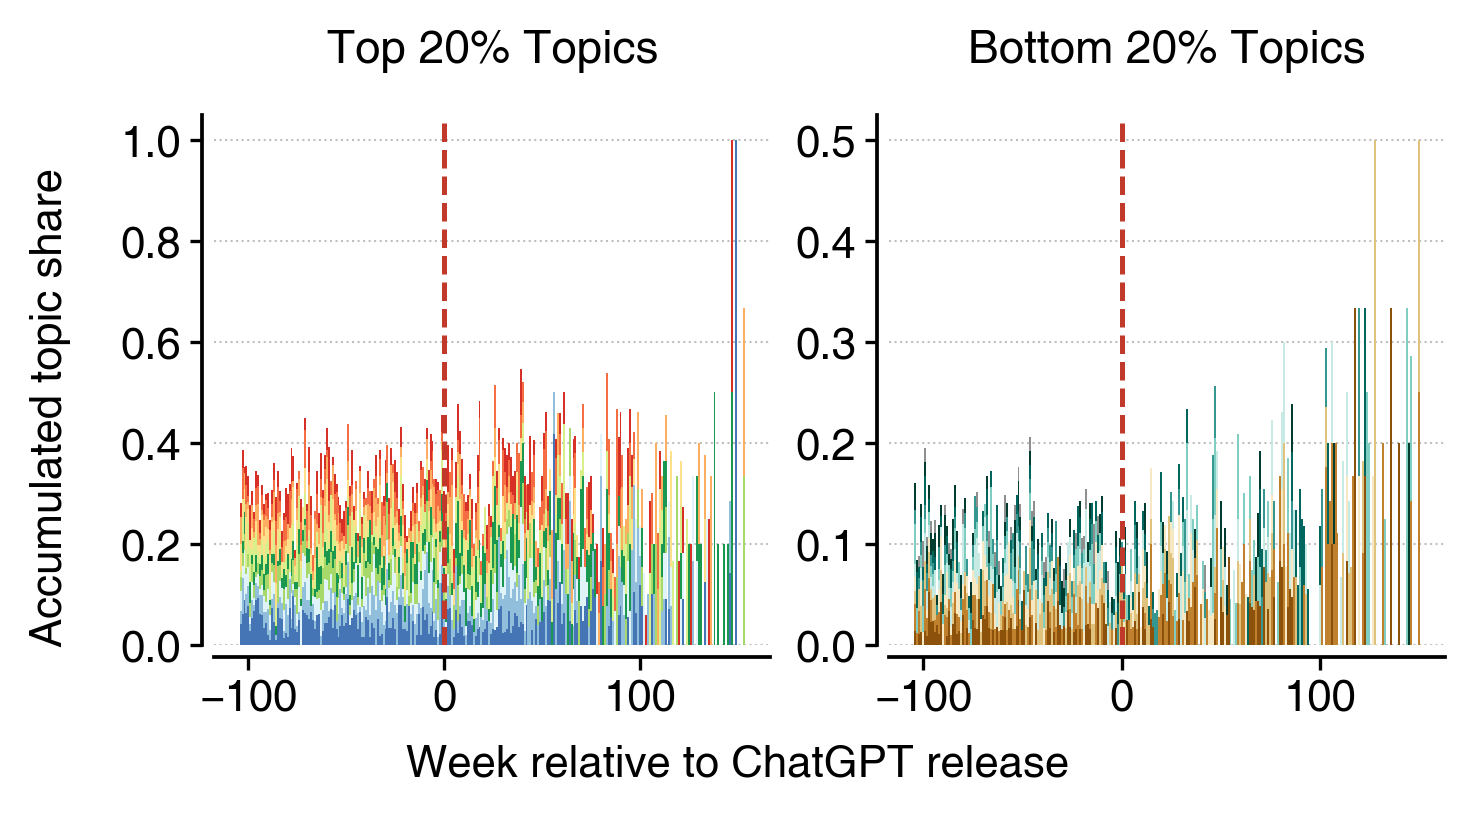

[Start....] drawing figures for assembly language


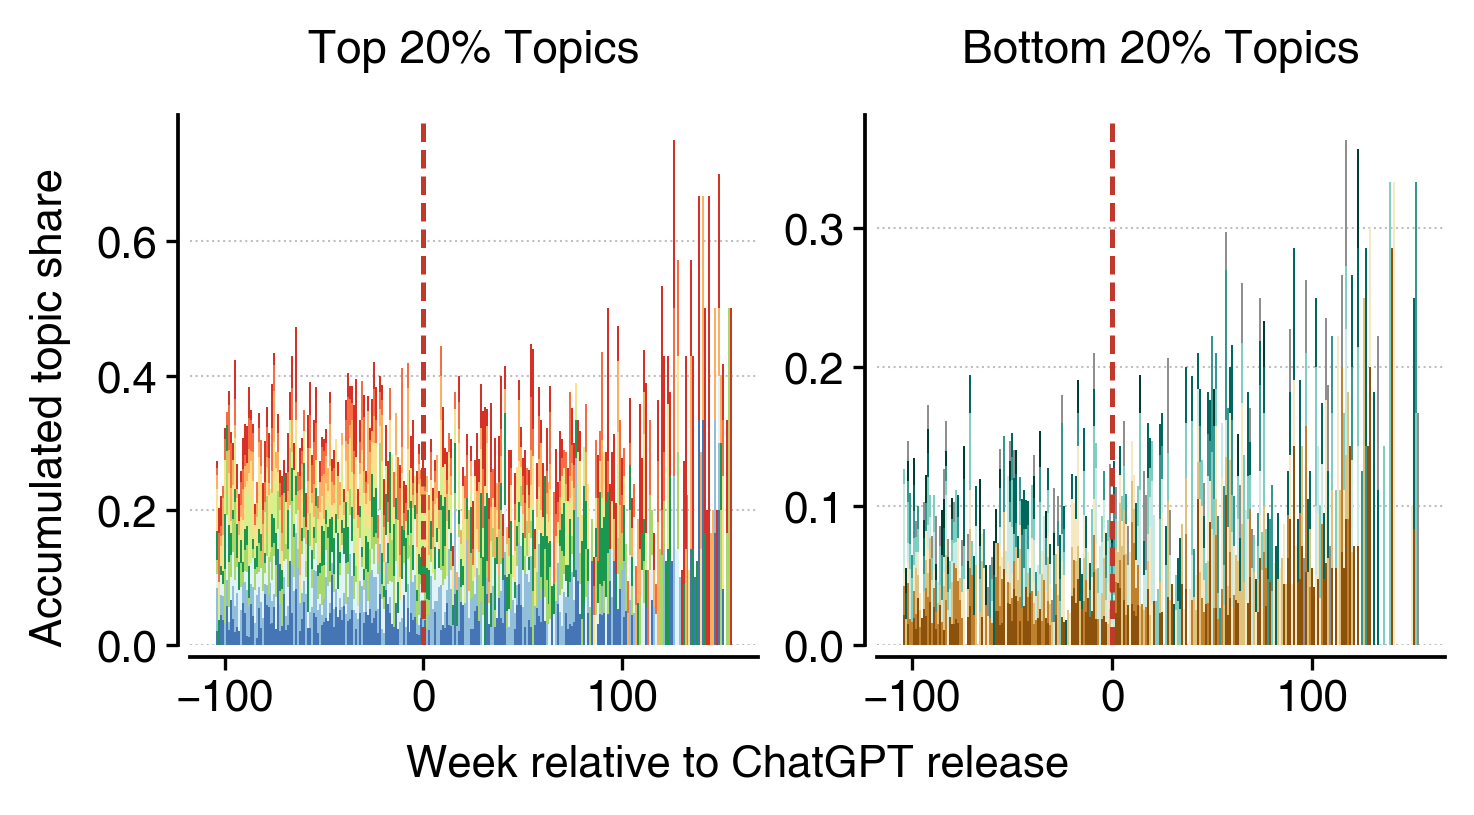

[Start....] drawing figures for haskell language


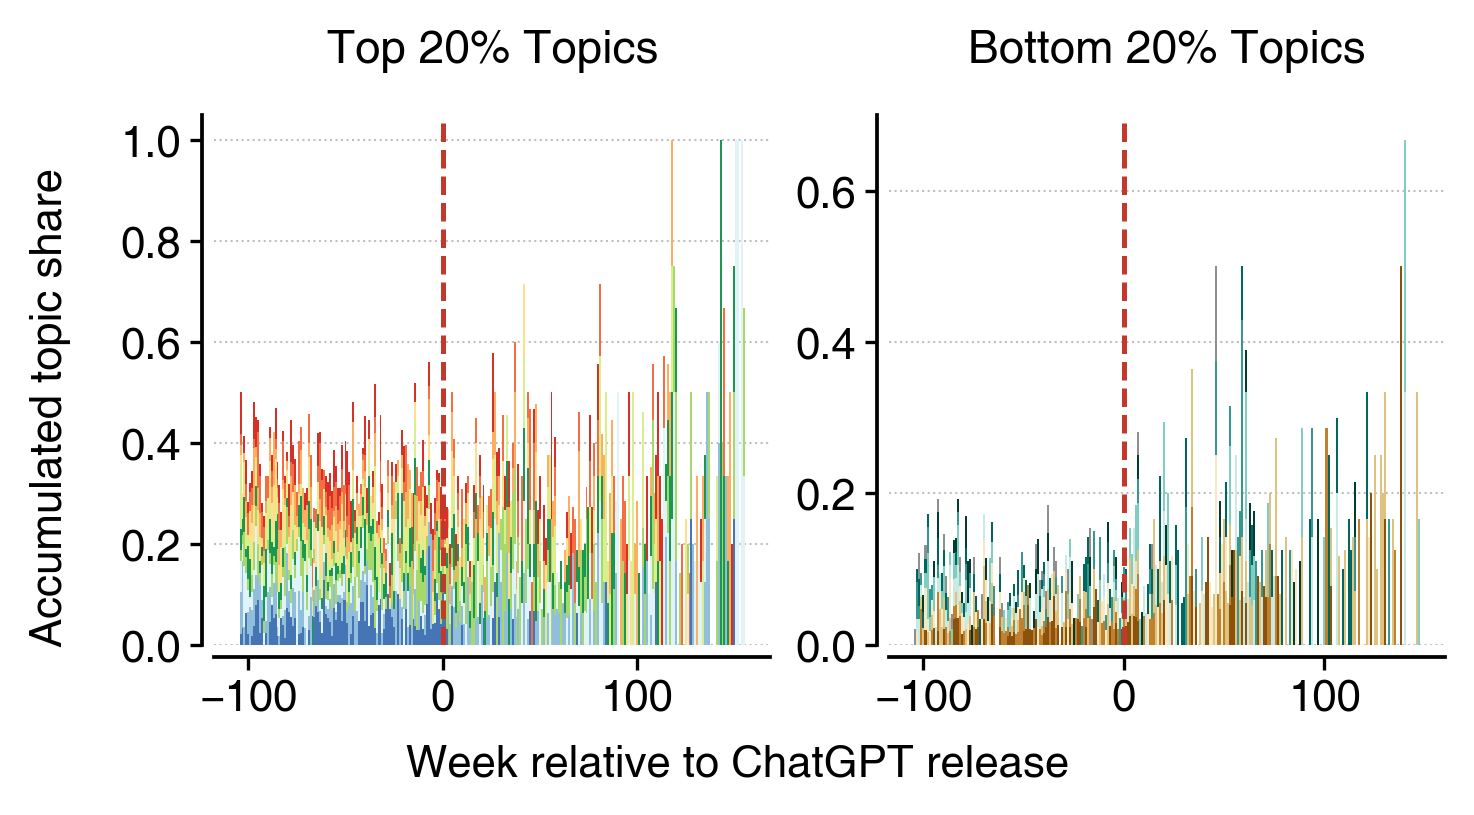

[Start....] drawing figures for delphi language


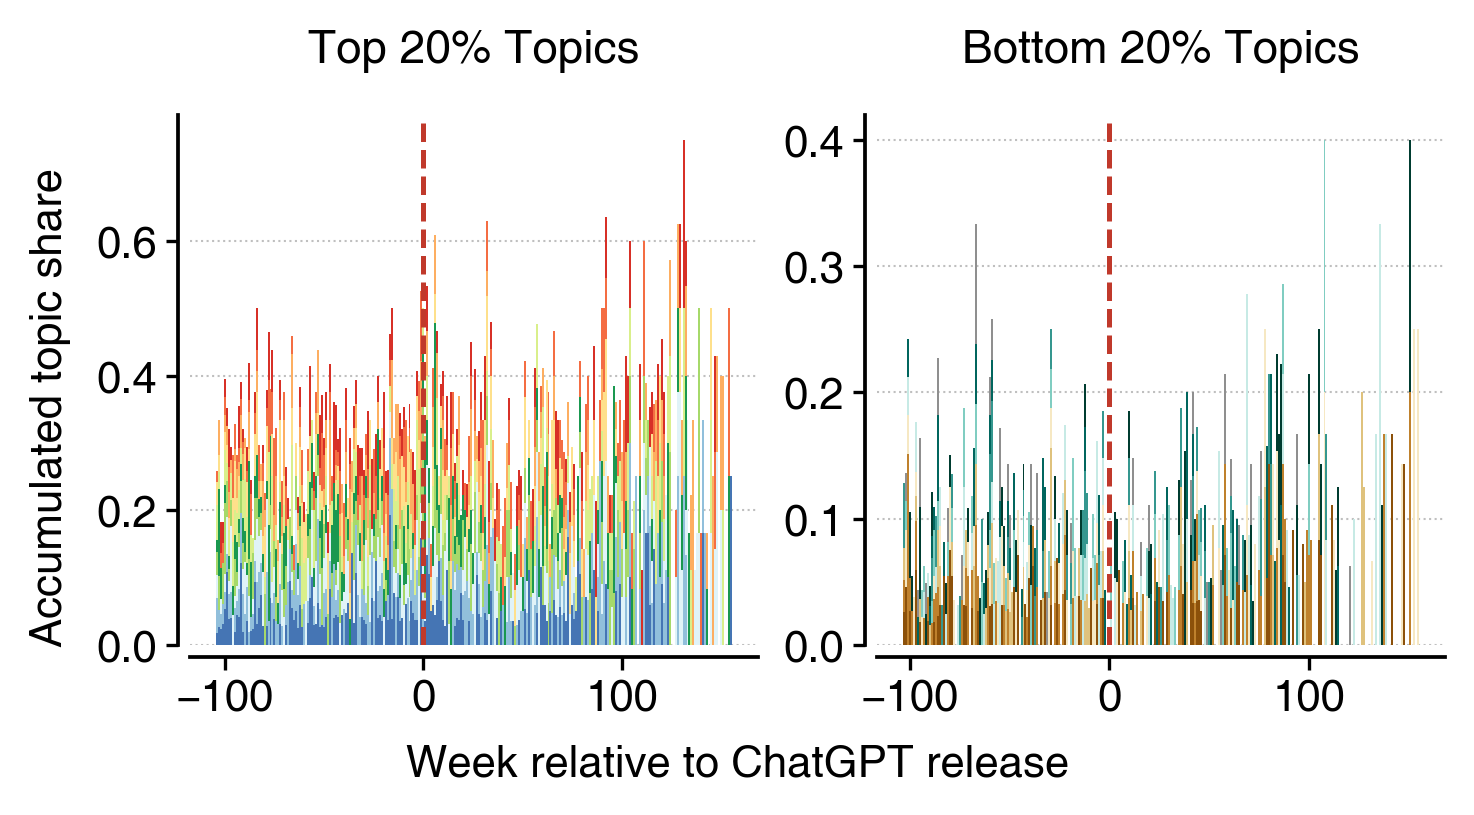

[Start....] drawing figures for lua language


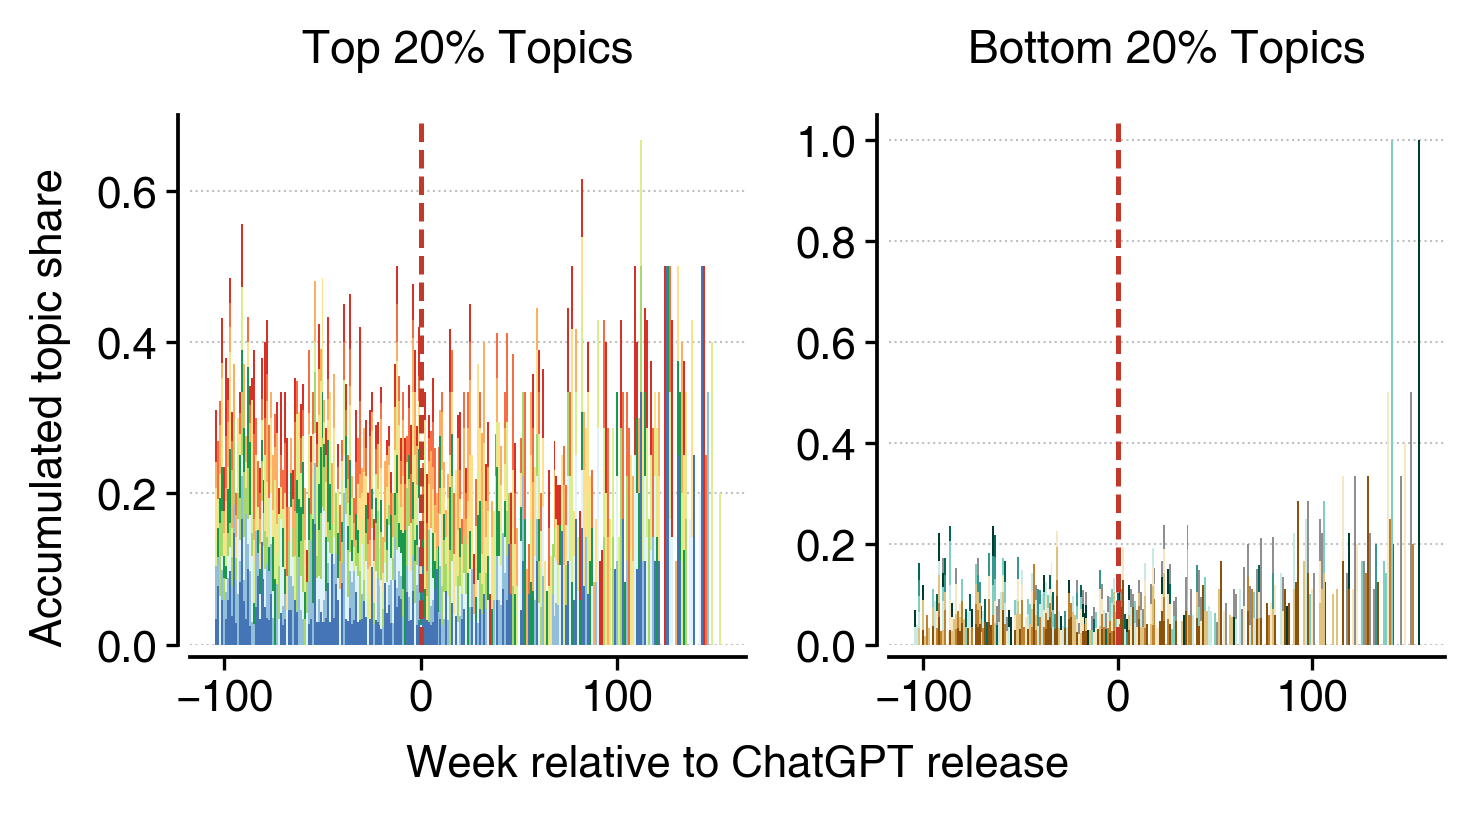

[Start....] drawing figures for perl language


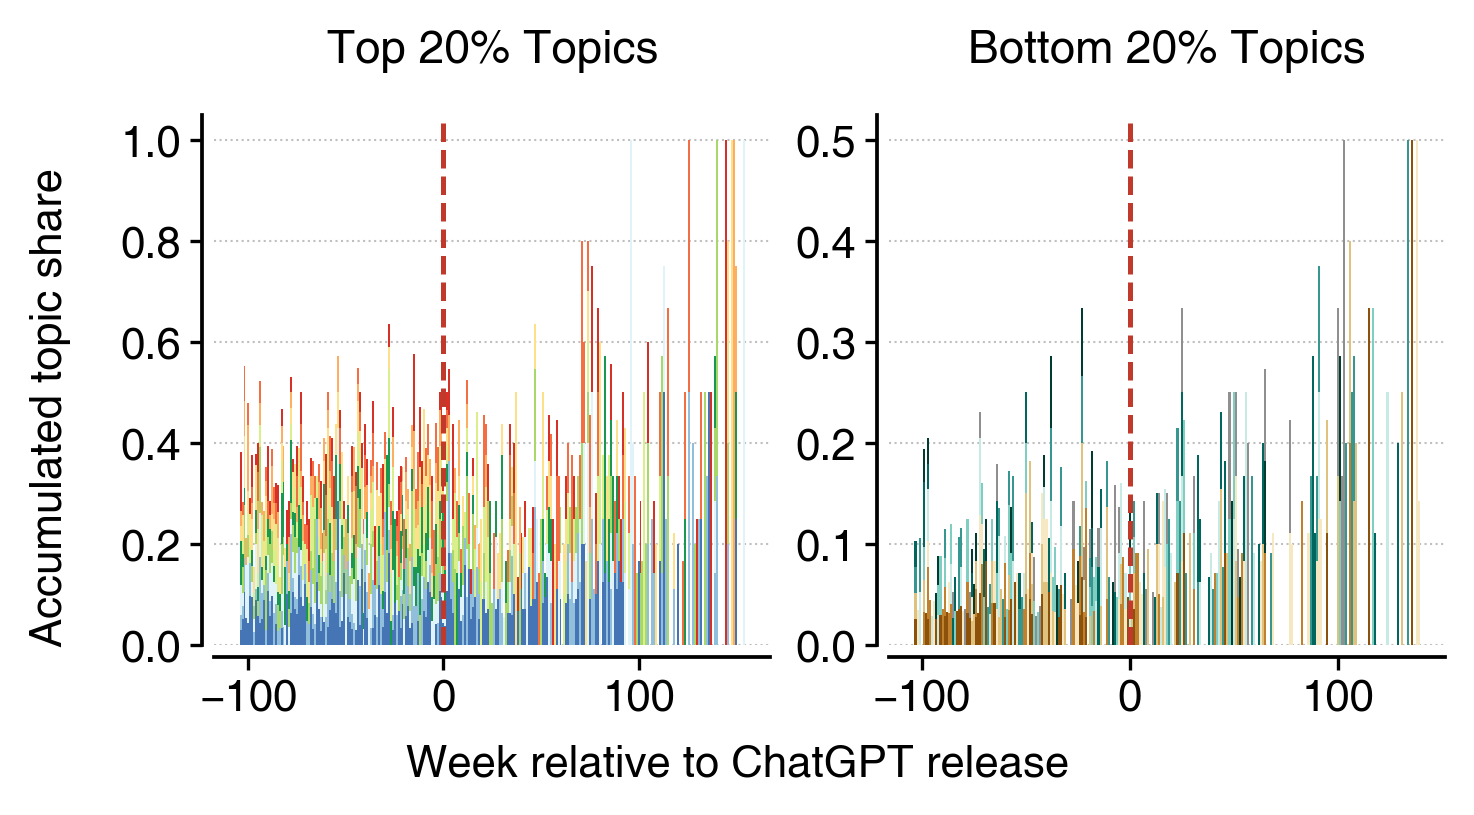

[Start....] drawing figures for prolog language


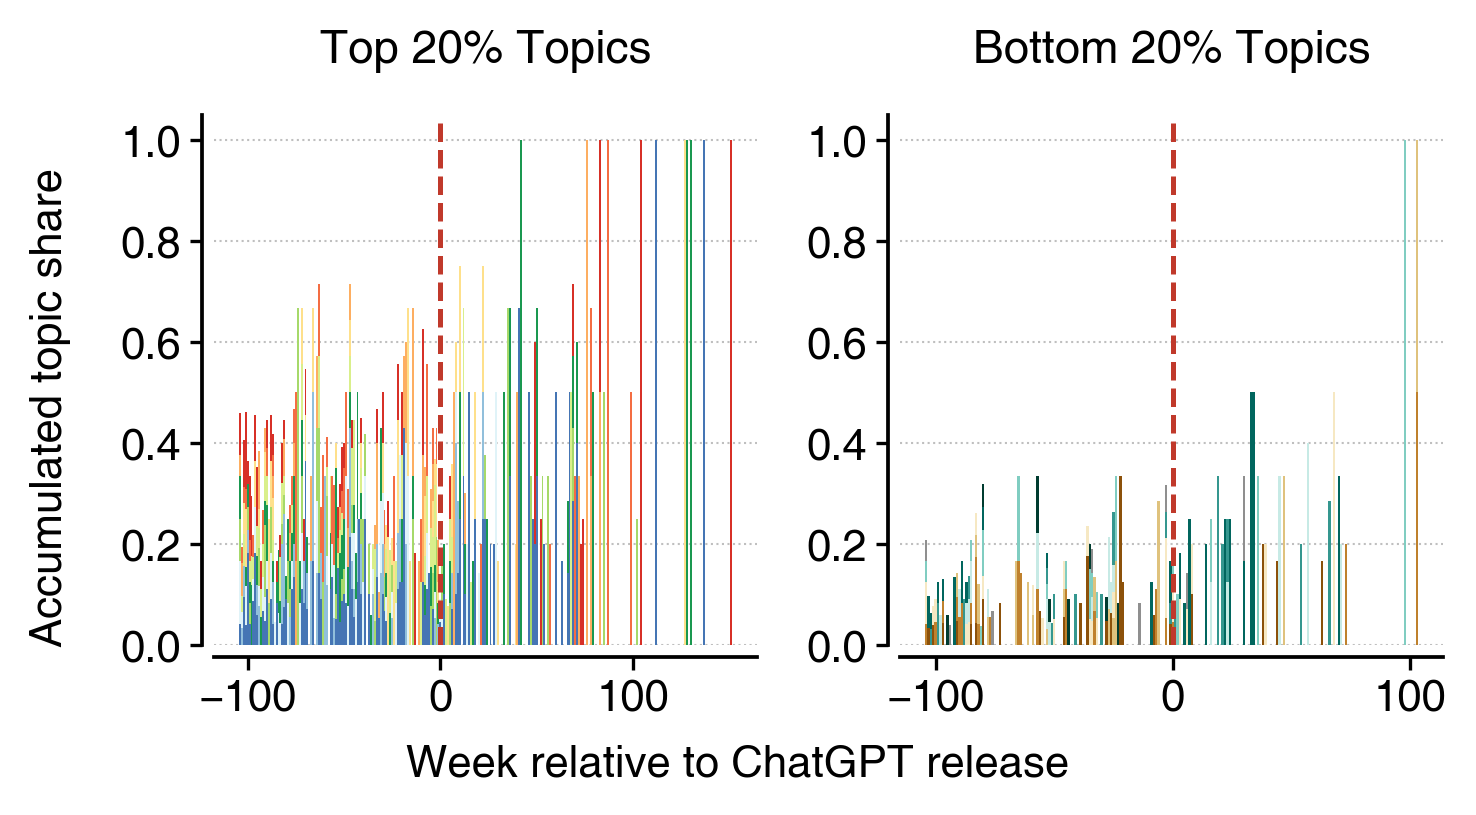

[Start....] drawing figures for fortran language


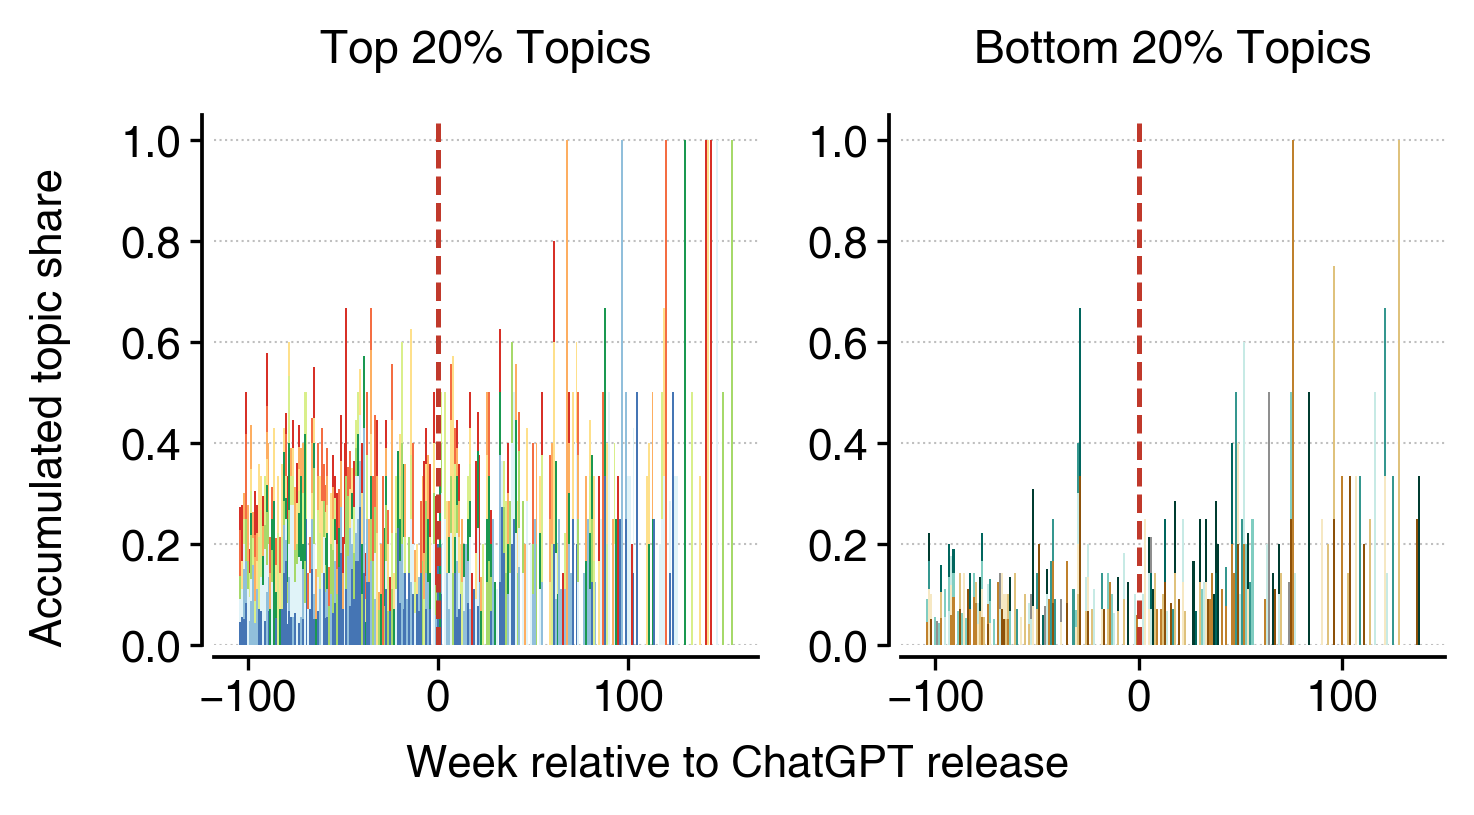

[Start....] drawing figures for f# language


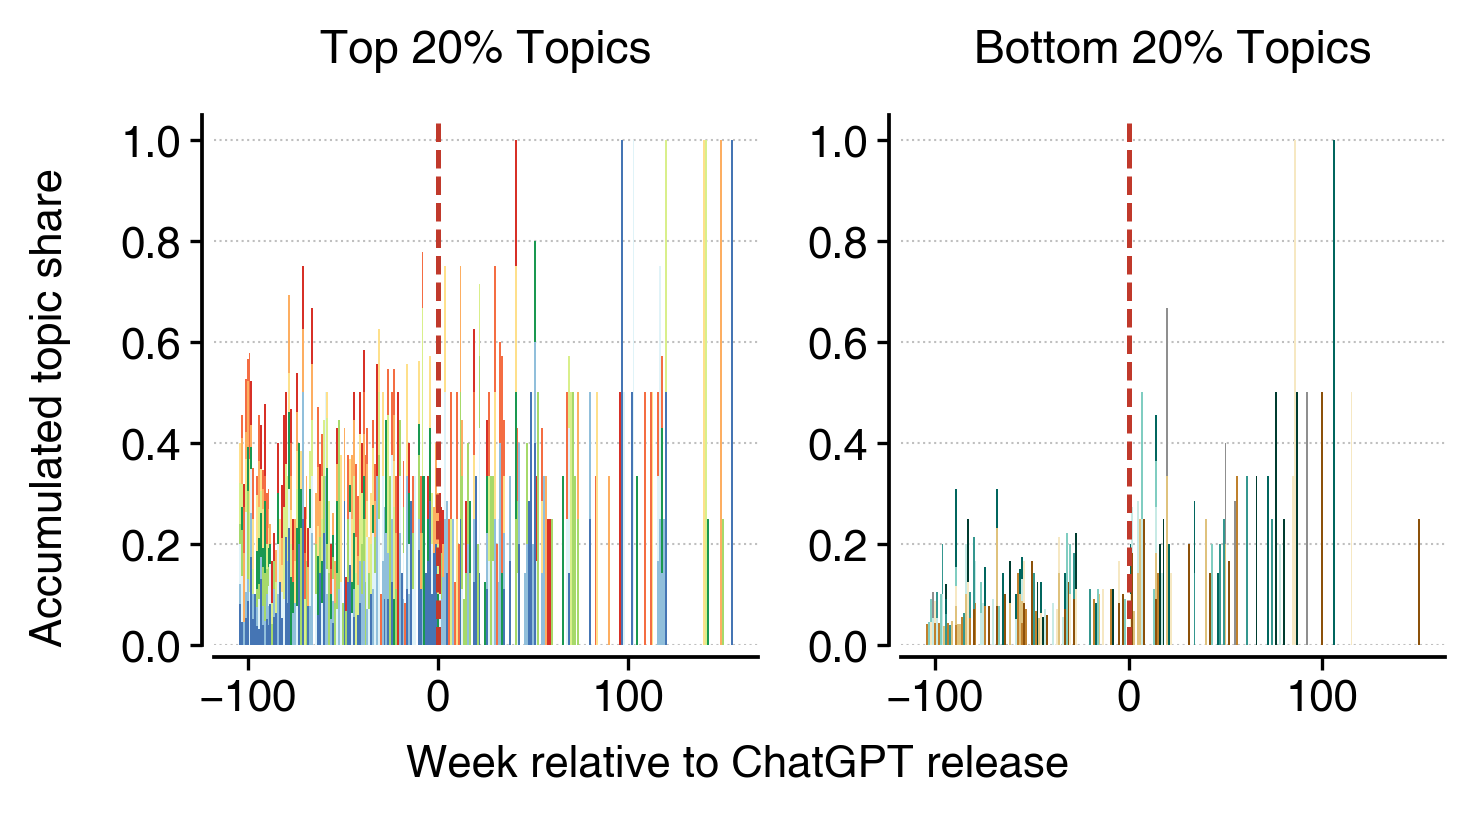

[Start....] drawing figures for solidity language


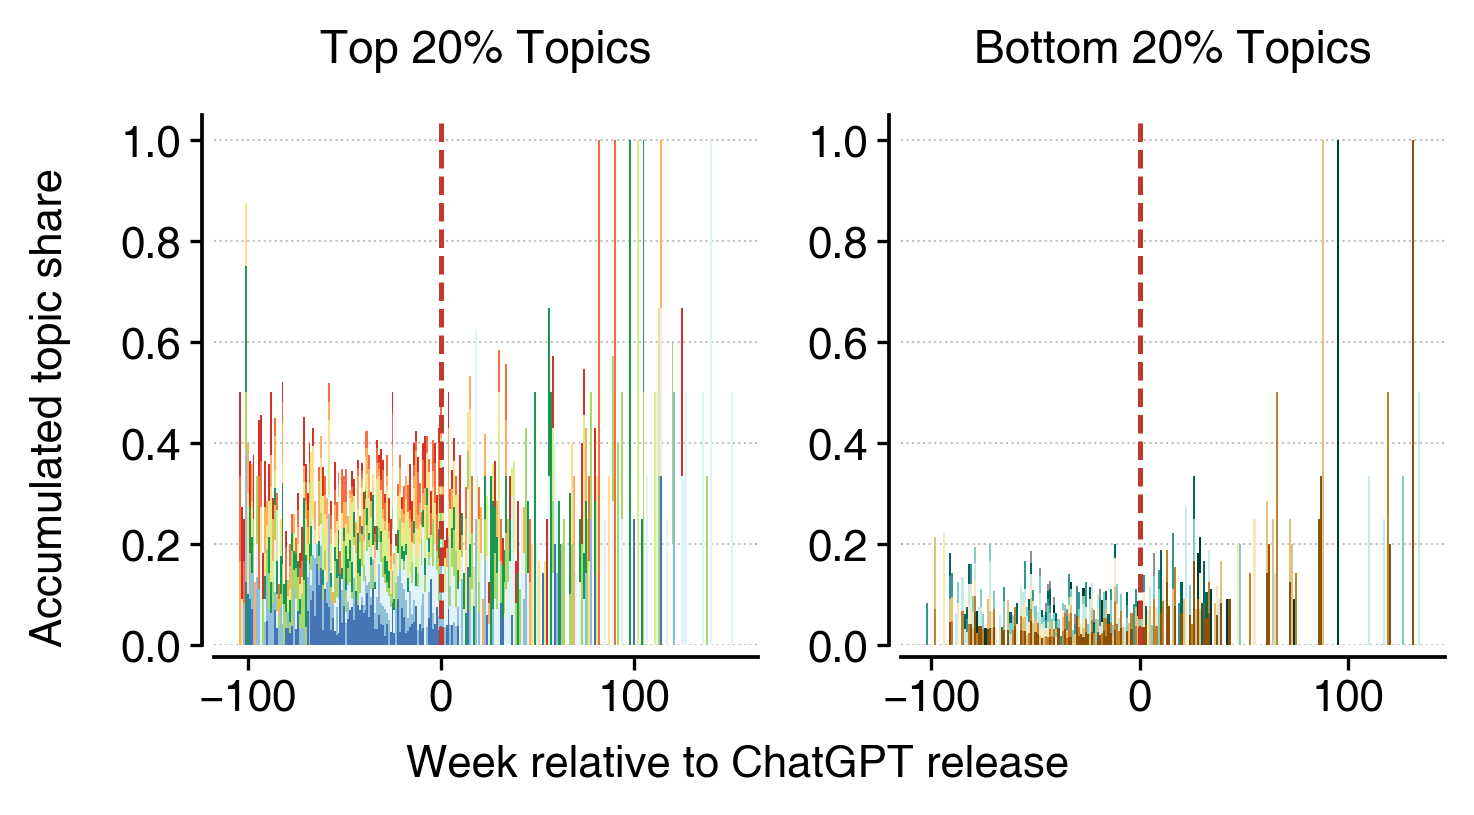

In [7]:
idx = 0
for idx, lang in enumerate(CONSTANTS.languages_from2020to2022) :
    print(f'[Start....] drawing figures for {lang} language')
    plotgen = PlotGen(idx = 200+idx, model_in_run='bert_based')
    

    tmp = load_df(plotgen.data_dir, ['id' , 'creationdate' , 'title', 'tags', 'body', 'Topic'])
    tmp = calc_rel_period(tmp, plotgen.std_date, date_col = 'creationdate', period = 7).reset_index()
    
    proportion_dict = dict()
    prop_df = proportion_calc_for_topic(tmp, 'rel_week', 'Topic')

    top10list, mid30list, bot10list = collect_top_bottom_topic(prop_df, 'rel_week', 'Topic', 'proportion')

    list_10 = {'Top 20% Topics' : top10list, 
                'Bottom 20% Topics' : bot10list, 
                'Mid 60% Topics': mid30list}


    proportion_dict = {     'Top 20% Topics'        : sort_distribution_by_list(prop_df, top10list),   
                            'Bottom 20% Topics'     : sort_distribution_by_list(prop_df, bot10list),}


    draw_bar_plot_for_bertopic(idx, proportion_dict, list_10, plotgen)

    # model_in_run = 'bert_based'
    # viz_dir = f'{path_list["data_root_dir"]}/result/{model_in_run}/{visualization_target}'
    # data_dir = f"{viz_dir}/data"
    # option_dict = load_json(f"{viz_dir}/option.json")
    # output_dir = './fig/'
    # date_range = 'Weekly'
    # std_date = Date_Setting[option_dict['year_range']]['std_date']

    # df = load_df(data_dir, ['id' , 'creationdate' , 'title', 'tags', 'body', 'Topic'])
    # df['creationdate'] = pd.to_datetime(df['creationdate'], format="mixed").dt.normalize()
    # df['rel_week'] = ((df['creationdate'] - std_date).dt.days // 7)

    # proportion_dict = dict()
    # prop_df = proportion_calc_for_topic(df, 'rel_week', 'Topic')

    # top10list, mid30list, bot10list = collect_top_bottom_topic(prop_df, 'rel_week', 'Topic', 'proportion')

    # list_10 = {'Top 20% Topics' : top10list, 
    #             'Bottom 20% Topics' : bot10list, 
    #             'Mid 60% Topics': mid30list}


    # proportion_dict = {     'Top 20% Topics'        : sort_distribution_by_list(prop_df, top10list),   
    #                         'Mid 60% Topics'        : sort_distribution_by_list(prop_df, mid30list),
    #                         'Bottom 20% Topics'     : sort_distribution_by_list(prop_df, bot10list),}

    # draw_bar_plot_for_bertopic(idx, proportion_dict, list_10,option_dict, output_dir)
    # draw_scatter_line_plot_for_bertopic(idx, proportion_dict, option_dict, output_dir)


    

In [8]:
proportion_dict

{'Top 20% Topics':       rel_week  Topic  cnt  tot_cnt  proportion
 1       -104.0      9    1        6    0.166667
 3       -104.0     17    1        6    0.166667
 4       -104.0     25    1        6    0.166667
 6       -103.0      8    1       11    0.090909
 9       -103.0     25    2       11    0.181818
 ...        ...    ...  ...      ...         ...
 3245     127.0      0    1        2    0.500000
 3252     136.0      0    1        2    0.500000
 3254     138.0      4    1        3    0.333333
 3258     140.0      0    1        1    1.000000
 3263     151.0      0    1        2    0.500000
 
 [905 rows x 5 columns],
 'Bottom 20% Topics':       rel_week  Topic  cnt  tot_cnt  proportion
 25      -102.0     46    1       12    0.083333
 60       -98.0     39    1       14    0.071429
 61       -98.0     40    2       14    0.142857
 94       -94.0     45    2        9    0.222222
 128      -91.0     33    1       22    0.045455
 ...        ...    ...  ...      ...         ...
 32